# Анализ данных и подготовка признаков — Предсказание выкупа заказов

**Задача:** по данным AmoCRM предсказать, выкупит ли клиент заказ наложенным платежом (binary classification: `buyout_flag`).

**Контекст:** интернет-магазин товаров для здоровья отправляет заказы через Почту России и СДЭК наложенным платежом. Часть клиентов не забирает товар — это приводит к расходам на доставку и возврат. Данные: выгрузка из AmoCRM за период март 2025 — март 2026, одна строка = одна сделка.

**Ключевой инсайт:** повторные клиенты (`contact_Число сделок >= 1`) выкупают в 97%+ случаев — для них достаточно модели на одном признаке. Основная сложность — **новые клиенты** (buyout ~32.5%), для которых строится LogReg на ~27 признаках.

Этот ноутбук:
1. Загружает и очищает данные
2. Показывает общий обзор и обосновывает фокус на новых клиентах
3. Переключается на новых клиентов и строит EDA по признакам для обучения
4. Создаёт новые признаки (через YAML-driven pipeline)
5. Разделяет данные на train/test/val (60/20/20) и сохраняет для ноутбука обучения

In [1]:
import pandas as pd
import numpy as np
import json
import os
import pickle
import warnings
import calendar
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from utils import load_feature_config, build_features

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)


In [ ]:
# === Вспомогательные функции визуализации ===
GREEN = '#2ecc71'
RED = '#e74c3c'
LIGHT_GRAY = '#ecf0f1'

LEAD_QUAL_ORDER = ['А - лид', 'В - лид', 'С - лид', 'D/Неквал лид', 'D - лид', 'Е - лид', 'Неквал лид']

CUSTOM_ORDERS = {
    '_deal_group': ['0 (новый)', '1', '2', '3', '4', '5+'],
    'price_bin': ['0-5k', '5-8k', '8-15k', '15k+', 'unknown'],
    'cart_bin': ['1-8', '9-12', '13+'],
    'manager_bin': ['0-800', '800-1.8k', '1.8-3k', '3k+'],
    'delta_bin': ['<30мин', '30-60мин', '1-2ч', '>2ч'],
}

def _ordered_categories(col, counts_index, n_tot):
    """Порядок меток: спецпорядок для известных столбцов, иначе по количеству."""
    idx_set = set(counts_index)
    def by_total_desc(keys):
        return sorted(keys, key=lambda x: -int(n_tot.loc[x]))

    if col in CUSTOM_ORDERS:
        return [c for c in CUSTOM_ORDERS[col] if c in idx_set]

    if col == 'sale_weekday':
        nums = sorted([x for x in idx_set if str(x).isdigit()], key=lambda x: int(x))
        rest = [x for x in idx_set if not str(x).isdigit()]
        return nums + by_total_desc(rest)

    if col == 'lead_Квалификация лида':
        order = [q for q in LEAD_QUAL_ORDER if q in idx_set]
        rest = [x for x in idx_set if x not in order]
        return order + by_total_desc(rest)

    return by_total_desc(list(idx_set))


def plot_feature_two_panel(df, col, title, top_n=None):
    """Категориальный признак: верх - count bars, низ - stacked 100% bars."""
    work = df
    if top_n is not None:
        keep = df[col].value_counts().head(top_n).index
        work = df.loc[df[col].isin(keep)]
    g = work.groupby(col, observed=True)['buyout_flag']
    n_buy = g.sum()
    n_tot = g.count()
    n_cancel = n_tot - n_buy
    rate = (n_buy / n_tot.replace(0, np.nan)).fillna(0.0)

    order = _ordered_categories(col, n_buy.index, n_tot)
    n_buy = n_buy.reindex(order, fill_value=0)
    n_cancel = n_cancel.reindex(order, fill_value=0)
    rate = rate.reindex(order, fill_value=0)

    labels = [str(x) for x in order]
    x = np.arange(len(labels))
    w = 0.36

    _fw, _fh = (14, 9) if top_n is not None else (11, 8)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(_fw, _fh), sharex=True)
    fig.suptitle(title, fontsize=13)

    ax1.bar(x - w/2, n_buy.values, width=w, color=GREEN, label='Выкуп (продажи)')
    ax1.bar(x + w/2, n_cancel.values, width=w, color=RED, label='Отмена (без выкупа)')
    ax1.set_ylabel('Количество')
    ax1.legend(loc='center right')
    ax1.grid(axis='y', alpha=0.3, zorder=0)

    # Нижний график: stacked bars. Пустые бины (n_tot=0) оставляем серыми.
    n_tot_vals = (n_buy + n_cancel).values
    for i_bar in range(len(x)):
        if n_tot_vals[i_bar] == 0:
            ax2.bar(x[i_bar], 1.0, color=LIGHT_GRAY, edgecolor='#bdc3c7', linewidth=0.5)
        else:
            ax2.bar(x[i_bar], rate.values[i_bar], color=GREEN)
            ax2.bar(x[i_bar], 1.0 - rate.values[i_bar], bottom=rate.values[i_bar], color=RED)

    ax2.set_ylabel('Доля')
    ax2.set_ylim(0, 1)
    from matplotlib.patches import Patch
    legend_handles = [Patch(color=GREEN, label='Доля выкупа'),
                      Patch(color=RED, label='Доля отмен')]
    if 0 in n_tot_vals:
        legend_handles.append(Patch(color=LIGHT_GRAY, label='Нет данных'))
    ax2.legend(handles=legend_handles, loc='center right')
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3, zorder=0)

    tbl = pd.DataFrame({
        'выкуп': n_buy.astype(int).values,
        'без_выкупа': n_cancel.astype(int).values,
        'всего': (n_buy + n_cancel).astype(int).values,
        'buyout_rate': rate.values,
    }, index=labels)
    tbl.index.name = col
    print(f"\n{'=' * 60}\n{title}\n{'=' * 60}")
    print(tbl.to_string(float_format='%.3f'))

    plt.tight_layout(); plt.show()


def plot_numeric_buyout_by_hist(df, col, title=None, bins=30, xlim=None):
    """Числовой признак: верх - наложенные гистограммы, низ - доля выкупа по бинам."""
    if title is None:
        title = col
    s = pd.to_numeric(df[col], errors='coerce')
    mask = s.notna()
    if not mask.any():
        print(f'\n{col}: нет данных (всё NaN), пропуск\n')
        return
    vals = s[mask].to_numpy(dtype=float)
    buy = df.loc[mask, 'buyout_flag'].astype(bool).to_numpy()

    hist_range = None
    lo_r = hi_r = None
    if xlim is not None:
        lo_r, hi_r = xlim[0], xlim[1]
        if lo_r is None: lo_r = float(np.min(vals))
        if hi_r is None: hi_r = float(np.max(vals))
        win = (vals >= lo_r) & (vals <= hi_r)
        vals_f, buy_f = vals[win], buy[win]
        if vals_f.size == 0:
            print(f'\n{col}: нет точек в xlim, пропуск\n')
            return
        hist_range = (lo_r, hi_r)
    else:
        vals_f, buy_f = vals, buy

    _, edges = np.histogram(vals_f, bins=bins, range=hist_range) if hist_range else np.histogram(vals_f, bins=bins)
    nbins = len(edges) - 1
    idx = np.clip(np.searchsorted(edges, vals_f, side='right') - 1, 0, nbins - 1)

    n_tot = np.bincount(idx, minlength=nbins)[:nbins].astype(int)
    n_buy_arr = np.bincount(idx[buy_f], minlength=nbins)[:nbins].astype(int)
    n_cancel_arr = n_tot - n_buy_arr
    rate = np.divide(n_buy_arr.astype(float), n_tot, out=np.full(nbins, np.nan), where=n_tot > 0)

    left = edges[:-1]
    widths = np.diff(edges)
    mean_v = float(np.mean(vals_f))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True,
                                    gridspec_kw={'height_ratios': [1, 1.25]})
    fig.suptitle(f'{title} (bins={nbins})', fontsize=13)

    ax1.hist(vals_f[buy_f], bins=edges, color=GREEN, alpha=0.55,
             label='Выкуп (продажи)', edgecolor='none')
    ax1.hist(vals_f[~buy_f], bins=edges, color=RED, alpha=0.55,
             label='Отмена (без выкупа)', edgecolor='none')
    ax1.axvline(mean_v, color='black', linestyle='--', linewidth=1, label='Среднее', zorder=5)
    ax1.set_ylabel('Количество')
    ax1.legend(loc='upper right')
    ax1.grid(axis='y', alpha=0.3)

    # Нижний график: доля выкупа. Пустые бины оставляем белыми.
    for i_bar in range(nbins):
        if n_tot[i_bar] == 0:
            continue  # пустой бин - не рисуем ничего
        ax2.bar(left[i_bar], rate[i_bar], width=widths[i_bar], align='edge',
                color=GREEN, edgecolor='none', linewidth=0)
        ax2.bar(left[i_bar], 1.0 - rate[i_bar], width=widths[i_bar],
                bottom=rate[i_bar], align='edge', color=RED, edgecolor='none', linewidth=0)

    ax2.set_ylabel('Доля')
    ax2.set_xlabel(col)
    ax2.set_ylim(0, 1)
    from matplotlib.patches import Patch
    ax2.legend(handles=[Patch(color=GREEN, label='Доля выкупа'),
                        Patch(color=RED, label='Доля отмен')], loc='upper right')
    ax2.grid(axis='y', alpha=0.3)
    ax2.axvline(mean_v, color='black', linestyle='--', linewidth=1, zorder=5)

    if hist_range is not None:
        ax2.set_xlim(lo_r, hi_r)

    bin_lbl = [f'[{left[i]:.4g}, {edges[i+1]:.4g}]' for i in range(nbins)]
    tbl = pd.DataFrame({'выкуп': n_buy_arr, 'без_выкупа': n_cancel_arr, 'всего': n_tot}, index=bin_lbl)
    tbl.index.name = col
    print(f"\n{'=' * 60}\n{title}\n{'=' * 60}")
    print(tbl.to_string())

    plt.tight_layout(); plt.show()

print('Функции визуализации определены')

Функции визуализации определены


: 

: 

: 

: 

## 1. Загрузка и очистка данных

Датасет содержит записи о заказах из AmoCRM за период март 2025 — март 2026. Каждая строка — одна сделка (lead) с информацией о клиенте, товаре, доставке и статусе.

Очистка:
- Убираем строки с `outcome_unknown == True` — сделки, по которым исход ещё неизвестен
- Приводим `buyout_flag` к бинарному формату (0/1)
- Конвертируем типы столбцов (даты, числа)

In [ ]:
DATA_PATH = 'dataset_2025-03-01_2026-03-29_external.csv'

df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Загружено строк: {len(df_raw)}")

# Убираем строки с неизвестным исходом
df = df_raw[df_raw['outcome_unknown'] == False].copy()
print(f"С известным исходом: {len(df)}")

# Целевая переменная
df['buyout_flag'] = df['buyout_flag'].map(
    {'True': 1, 'true': 1, True: 1, 'False': 0, 'false': 0, False: 0}
).astype(int)

# Приведение типов
df['sale_ts'] = pd.to_numeric(df['sale_ts'], errors='coerce')
df['lead_created_at'] = pd.to_numeric(df['lead_created_at'], errors='coerce')
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')
df['lead_price'] = pd.to_numeric(df['lead_price'], errors='coerce')
df['contact_Число сделок'] = pd.to_numeric(df.get('contact_Число сделок'), errors='coerce')

for col in ['lead_Вес (грамм)*', 'lead_Длина', 'lead_Ширина', 'lead_Высота',
             'lead_Скидка', 'lead_Стоимость доставки', 'lead_Масса (гр)']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

buyout_rate = df['buyout_flag'].mean()
print(f"\nBuyout rate: {buyout_rate:.4f} ({buyout_rate*100:.1f}%)")
print(f"Выкуп: {df['buyout_flag'].sum()}, Отказ: {(1 - df['buyout_flag']).sum():.0f}")

Загружено строк: 18887
С известным исходом: 17966

Buyout rate: 0.8283 (82.8%)
Выкуп: 14882, Отказ: 3084


: 

: 

: 

: 

In [ ]:
# === Коррекция интегральной характеристики contact_Число сделок ===
# CRM хранит ТЕКУЩЕЕ (финальное) значение для ВСЕХ записей контакта.
# Если у клиента 5 заказов, все 5 строк покажут contact_Число сделок = 5.
# Восстанавливаем реальное число сделок на момент каждой записи.

def add_real_deal_count(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Добавляет колонку real_Число сделок, вычисляя истинное число сделок
    на момент каждой записи.

    Алгоритм для каждого contact_id:
    - Сортируем записи по времени (от старых к новым).
    - Берём contact_Число сделок из самой новой записи — это максимум.
    - Для i-й записи: real = max - (n - 1 - i), где n = кол-во записей.
    - Если max < n (сломанная конформация): real = 0, 1, 2, ..., n-1.
    """
    df = df_raw.copy()
    df['contact_Число сделок'] = df['contact_Число сделок'].fillna(0)

    # Строки без contact_id — не можем вычислить, оставляем 0
    has_cid = df['contact_id'].notna()
    df_with = df[has_cid].sort_values(['contact_id', 'lead_created_at'])

    # Внутригрупповой ранг (0 = самая старая запись)
    df_with['_rank'] = df_with.groupby('contact_id').cumcount()
    df_with['_n'] = df_with.groupby('contact_id')['contact_id'].transform('size')
    df_with['_max'] = df_with.groupby('contact_id')['contact_Число сделок'].transform('last')

    # Сломанные конформации: CRM говорит меньше сделок, чем записей в датасете
    broken_mask = df_with['_max'] < df_with['_n']

    df_with['real_Число сделок'] = np.where(
        broken_mask,
        df_with['_rank'],
        df_with['_max'] - df_with['_n'] + 1 + df_with['_rank']
    )

    df['real_Число сделок'] = df_with['real_Число сделок']
    df['real_Число сделок'] = df['real_Число сделок'].fillna(0)  # NaN contact_id -> 0 (новый)
    df.drop(columns=[c for c in ['_rank', '_n', '_max'] if c in df.columns], inplace=True)
    return df.sort_index()


df = add_real_deal_count(df)

# --- Диагностика ---
is_new_old = (df['contact_Число сделок'] < 1)
is_new_fixed = (df['real_Число сделок'] < 1)

# Сломанные конформации (max_val в CRM < числа записей контакта)
has_cid = df['contact_id'].notna()
grp = df[has_cid].groupby('contact_id').agg(
    n_rows=('contact_id', 'size'),
    max_crm=('contact_Число сделок', 'max')
)
n_broken = (grp['max_crm'] < grp['n_rows']).sum()

print(f'Коррекция contact_Число сделок -> real_Число сделок:')
print(f'  Контактов с несколькими записями: {(grp["n_rows"] > 1).sum()}')
print(f'  Сломанных конформаций (CRM < записей): {n_broken}')
print(f'  Строк без contact_id (-> новые): {(~has_cid).sum()}')
print(f'  Были "повторные" -> "новые": {((~is_new_old) & is_new_fixed).sum()}')
print(f'  Были "новые" -> "повторные": {(is_new_old & (~is_new_fixed)).sum()}')

# Заменяем contact_Число сделок скорректированными значениями
# (downstream код и model.py используют contact_Число сделок;
#  при inference CRM отдаёт актуальное значение — коррекция не нужна)
df['contact_Число сделок'] = df['real_Число сделок']
df.drop(columns=['real_Число сделок'], inplace=True)

is_new = df['contact_Число сделок'] < 1
print(f'\nПосле коррекции:')
print(f'  Новые клиенты:    {is_new.sum()} строк')
print(f'  Повторные:        {(~is_new).sum()} строк')

Коррекция contact_Число сделок -> real_Число сделок:
  Контактов с несколькими записями: 1642
  Сломанных конформаций (CRM < записей): 4192
  Строк без contact_id (-> новые): 5
  Были "повторные" -> "новые": 294
  Были "новые" -> "повторные": 176

После коррекции:
  Новые клиенты:    4197 строк
  Повторные:        13769 строк


: 

: 

: 

: 

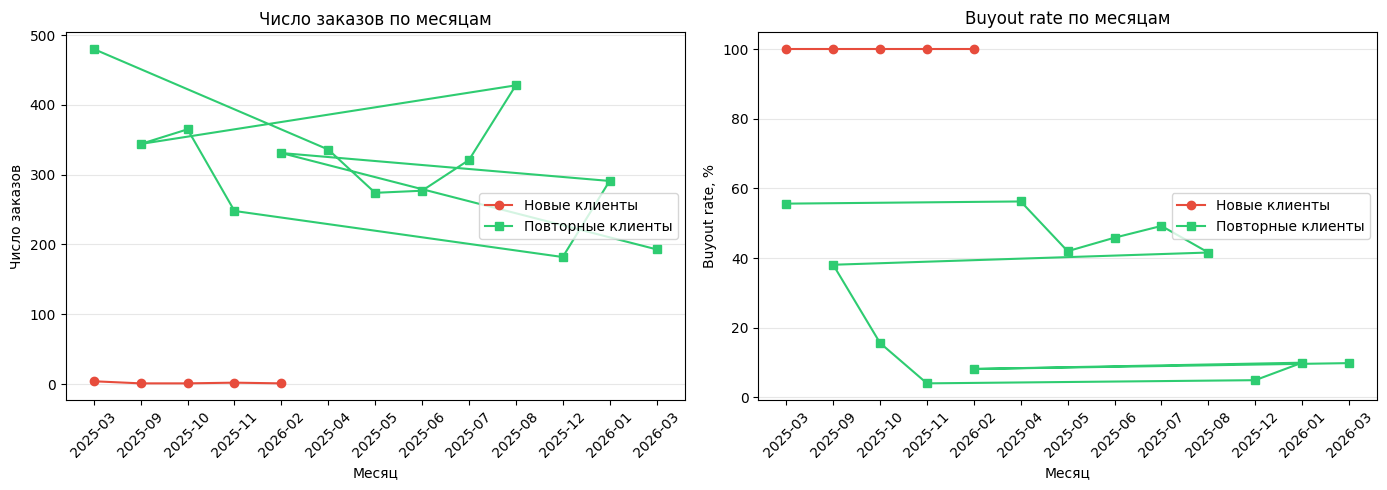

: 

: 

: 

: 

In [ ]:
# Динамика заказов и buyout rate по месяцам
df['_month'] = df['sale_date'].dt.to_period('M')
is_new = df['contact_Число сделок'] < 1

monthly = df.groupby(['_month', is_new.rename('is_new')]).agg(
    orders=('buyout_flag', 'size'),
    buyout_rate=('buyout_flag', 'mean')
).reset_index()

new_m = monthly[monthly['is_new']].set_index('_month')
ret_m = monthly[~monthly['is_new']].set_index('_month')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- График 1: число заказов по месяцам ---
ax = axes[0]
ax.plot(new_m.index.astype(str), new_m['orders'], marker='o', color=RED, label='Новые клиенты')
ax.plot(ret_m.index.astype(str), ret_m['orders'], marker='s', color=GREEN, label='Повторные клиенты')
ax.set_title('Число заказов по месяцам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Число заказов')
ax.legend(loc='center right')
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# --- График 2: buyout rate по месяцам ---
ax = axes[1]
ax.plot(new_m.index.astype(str), new_m['buyout_rate'] * 100, marker='o', color=RED, label='Новые клиенты')
ax.plot(ret_m.index.astype(str), ret_m['buyout_rate'] * 100, marker='s', color=GREEN, label='Повторные клиенты')
ax.set_title('Buyout rate по месяцам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Buyout rate, %')
ax.legend(loc='center right')
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

df.drop(columns=['_month'], inplace=True)

## 2. Общий обзор данных

Прежде чем строить модель, посмотрим на общую картину: распределение целевой переменной и buyout rate для двух ключевых групп клиентов — новых и повторных.

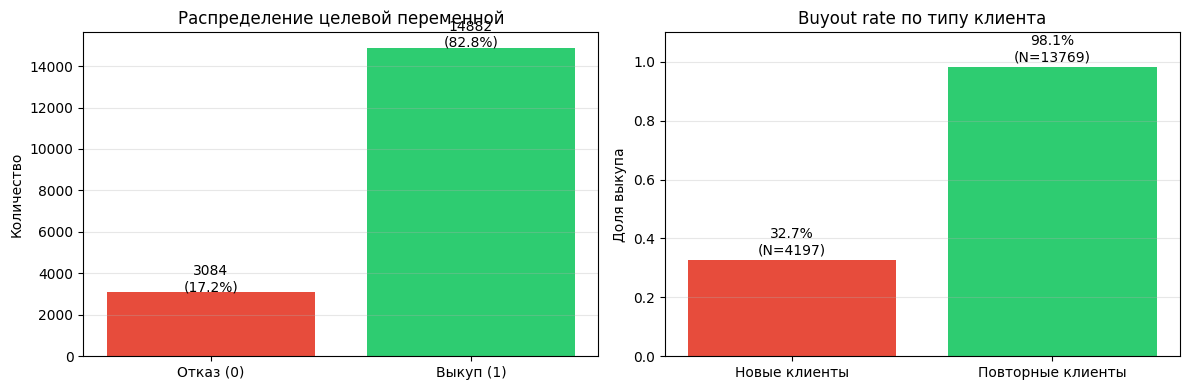

Всего строк: 17966
Новые клиенты: 4197 (23.4%), buyout: 0.3271
Повторные:     13769 (76.6%), buyout: 0.9811


: 

: 

: 

: 

In [ ]:
# Баланс классов
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['buyout_flag'].value_counts().sort_index()
axes[0].bar(['Отказ (0)', 'Выкуп (1)'], counts.values, color=[RED, GREEN])
axes[0].set_title('Распределение целевой переменной')
axes[0].set_ylabel('Количество')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v}\n({v/len(df)*100:.1f}%)', ha='center')
axes[0].grid(axis='y', alpha=0.3)

# Новые vs повторные
is_new = df['contact_Число сделок'].isna() | (df['contact_Число сделок'] < 1)
groups = pd.DataFrame({
    'type': ['Новые клиенты', 'Повторные клиенты'],
    'count': [is_new.sum(), (~is_new).sum()],
    'buyout_rate': [df.loc[is_new, 'buyout_flag'].mean(), df.loc[~is_new, 'buyout_flag'].mean()]
})

bars = axes[1].bar(groups['type'], groups['buyout_rate'], color=[RED, GREEN])
axes[1].set_title('Buyout rate по типу клиента')
axes[1].set_ylabel('Доля выкупа')
axes[1].set_ylim(0, 1.1)
for bar, rate, cnt in zip(bars, groups['buyout_rate'], groups['count']):
    axes[1].text(bar.get_x() + bar.get_width()/2, rate + 0.02,
                 f'{rate:.1%}\n(N={cnt})', ha='center')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Всего строк: {len(df)}")
print(f"Новые клиенты: {is_new.sum()} ({is_new.mean()*100:.1f}%), buyout: {df.loc[is_new, 'buyout_flag'].mean():.4f}")
print(f"Повторные:     {(~is_new).sum()} ({(~is_new).mean()*100:.1f}%), buyout: {df.loc[~is_new, 'buyout_flag'].mean():.4f}")

### Ключевой инсайт: два типа клиентов

Данные показывают радикальное различие между двумя группами:
- **Повторные клиенты** (77% заказов) — buyout 97%+. Клиент, заказывавший ранее, почти гарантированно выкупит снова. Предсказание тривиально: одного признака `contact_Число сделок` достаточно.
- **Новые клиенты** (23% заказов) — buyout ~32.5%. Именно здесь бизнес теряет деньги на доставке невыкупленных заказов, и именно здесь ML-модель принесёт наибольшую пользу.

Чтобы убедиться в этом визуально, построим buyout rate в разбивке по количеству прошлых заказов клиента:


Buyout rate по числу прошлых заказов клиента
             выкуп  без_выкупа  всего  buyout_rate
_deal_group                                       
0 (новый)     1373        2824   4197        0.327
1            10973         190  11163        0.983
2             1396          45   1441        0.969
3              471          14    485        0.971
4              240           4    244        0.984
5+             429           7    436        0.984


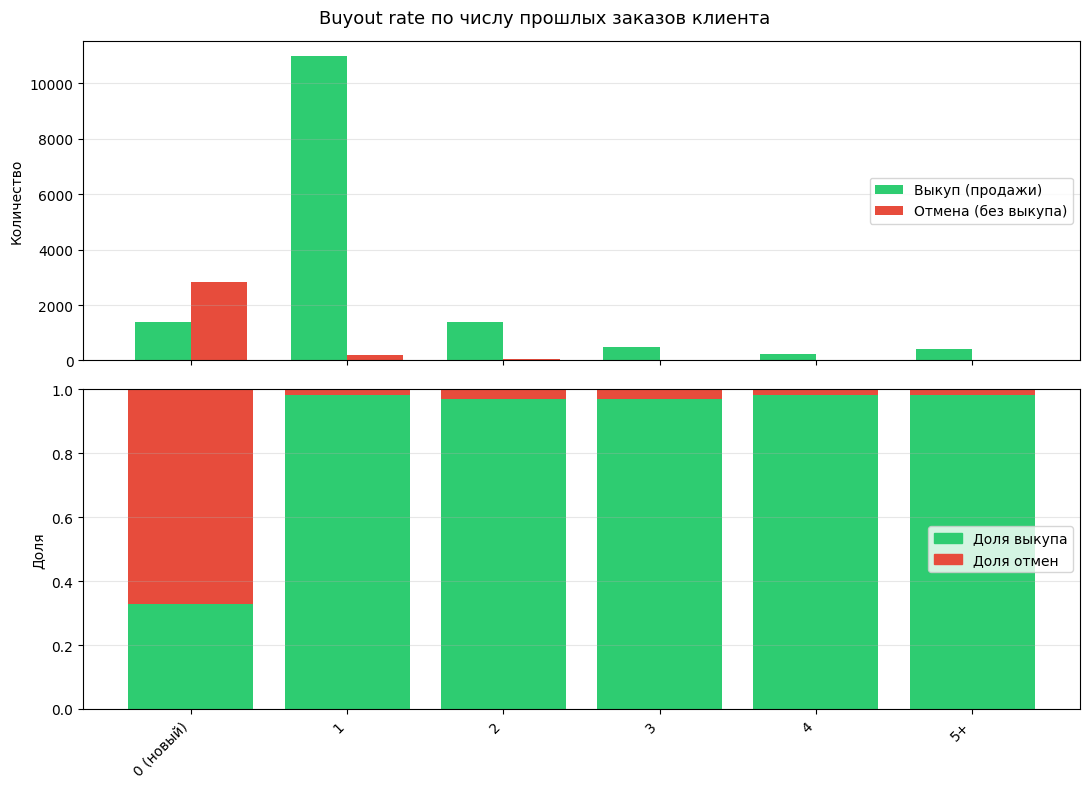

: 

: 

: 

: 

In [ ]:
# Группируем по числу прошлых сделок
deal_counts = df['contact_Число сделок'].fillna(0).astype(int)
deal_counts = deal_counts.clip(upper=5)
df['_deal_group'] = deal_counts.astype(str)
df.loc[df['_deal_group'] == '5', '_deal_group'] = '5+'
df.loc[df['_deal_group'] == '0', '_deal_group'] = '0 (новый)'

plot_feature_two_panel(df, '_deal_group', 'Buyout rate по числу прошлых заказов клиента')

df.drop(columns=['_deal_group'], inplace=True)

## 3. Фокус на новых клиентах

График выше наглядно демонстрирует: начиная с 1-го прошлого заказа buyout rate >96%. Анализировать и моделировать повторных клиентов нет смысла — для них достаточно простой модели на одном признаке.

**С этого момента весь дальнейший анализ проводится только на новых клиентах** — записях, где `contact_Число сделок` = NaN или 0. Именно для этого сегмента строится основная ML-модель.

In [ ]:
# Сохраняем полный датасет для финального разделения
df_full = df.copy()

# Переключаемся на новых клиентов
is_new = df['contact_Число сделок'].isna() | (df['contact_Число сделок'] < 1)
df = df[is_new].copy()

print(f'Новые клиенты: {len(df)}')
print(f'Buyout rate: {df["buyout_flag"].mean():.4f} ({df["buyout_flag"].mean()*100:.1f}%)')
print(f'Выкуп: {df["buyout_flag"].sum()}, Отказ: {(1 - df["buyout_flag"]).sum():.0f}')

Новые клиенты: 4197
Buyout rate: 0.3271 (32.7%)
Выкуп: 1373, Отказ: 2824


: 

: 

: 

: 

In [ ]:
# === YAML-driven feature pipeline ===
# 1. Конфиг признаков (см. features.yaml)
config = load_feature_config('features.yaml')

# 2. Гео-словарь (база городов России + Крым)
with open('russia-cities.json', encoding='utf-8') as f:
    _russia_cities_raw = json.load(f)
russia_cities = [{'name': c['name'], 'region': c['region']['fullname']}
                 for c in _russia_cities_raw if c.get('name')]
russia_cities.extend([
    {'name': 'Ялта',            'region': 'Республика Крым'},
    {'name': 'Керчь',           'region': 'Республика Крым'},
    {'name': 'Севастополь',     'region': 'Севастополь'},
    {'name': 'Феодосия',        'region': 'Республика Крым'},
    {'name': 'Красноперекопск', 'region': 'Республика Крым'},
    {'name': 'Евпатория',       'region': 'Республика Крым'},
    {'name': 'Алушта',          'region': 'Республика Крым'},
])

# 3. Карта manager_id -> число сделок (агрегат по полному датасету)
manager_map = df_full.groupby('lead_responsible_user_id').size().to_dict()

# 4. Группы менеджеров по buyout rate новых клиентов.
#    Менеджеры с rate >= 40% → mgr_high, 20-40% → mgr_mid, <20% → mgr_low.
#    Различие в buyout rate между группами — до 30 п.п.
mgr_rates = df.groupby('lead_responsible_user_id')['buyout_flag'].mean()
mgr_group_map = {}
for mgr_id, rate in mgr_rates.items():
    mgr_group_map[mgr_id] = (
        'mgr_high' if rate >= 0.4 else
        'mgr_mid'  if rate >= 0.2 else
        'mgr_low'
    )

# 5. Карта крупных городов (население >= 500 тыс.)
big_city_map = {c['name']: 1 for c in _russia_cities_raw
                if c.get('population', 0) >= 500_000}

# 6. Препроцессинг — сразу для df новых клиентов (для EDA ниже)
context = {
    'manager_map': manager_map,
    'russia_cities': russia_cities,
    'mgr_group_map': mgr_group_map,
    'big_city_map': big_city_map,
}
df, feat_cols = build_features(df, config, context)

print(f'Признаки готовы: cat={len(feat_cols.cat_cols)}, num={len(feat_cols.num_cols)}, '
      f'bin={len(feat_cols.bin_cols)}, geo={len(feat_cols.geo_cols)}, te={len(feat_cols.te_cat_cols)}')
print(f'Гео-база: {len(russia_cities)} городов')
n_unknown = (df['city_clean'] == '__unknown__').sum()
print(f'Unknown городов: {n_unknown} ({n_unknown/len(df)*100:.1f}%)')
print(f'Крупных городов (>=500k): {len(big_city_map)}')
print(f'Групп менеджеров: { {v: sum(1 for x in mgr_group_map.values() if x == v) for v in sorted(set(mgr_group_map.values()))} }')

Признаки готовы: cat=15, num=0, bin=3, geo=2, te=0
Гео-база: 1109 городов
Unknown городов: 512 (12.2%)
Крупных городов (>=500k): 36
Групп менеджеров: {'mgr_high': 3, 'mgr_low': 19, 'mgr_mid': 5}


: 

: 

: 

: 

## 4. EDA — Категориальные признаки (новые клиенты)

Для каждого категориального признака, который будет использоваться в модели, строим двухпанельный график:
- **Верх:** количество выкупов и отказов по категориям (side-by-side bars)
- **Низ:** доля выкупа в каждой категории (stacked 100% bars)

Важно: для ряда признаков **NaN — это информативный класс**, а не пропуск. NaN в `lead_Квалификация лида`, `lead_Категория и варианты выбора`, `lead_Модель телефона` и `lead_будущие покупки` означает, что менеджер не звонил клиенту.

`lead_responsible_user_id` — идентификатор менеджера. В модели кодируется one-hot (26 уникальных менеджеров). L1-регуляризация обнуляет малозначимых менеджеров автоматически.


lead_Служба доставки
                      выкуп  без_выкупа  всего  buyout_rate
lead_Служба доставки                                       
СДЭК                    380        2172   2552        0.149
Почта                   986         639   1625        0.607
Прочее                    7          13     20        0.350


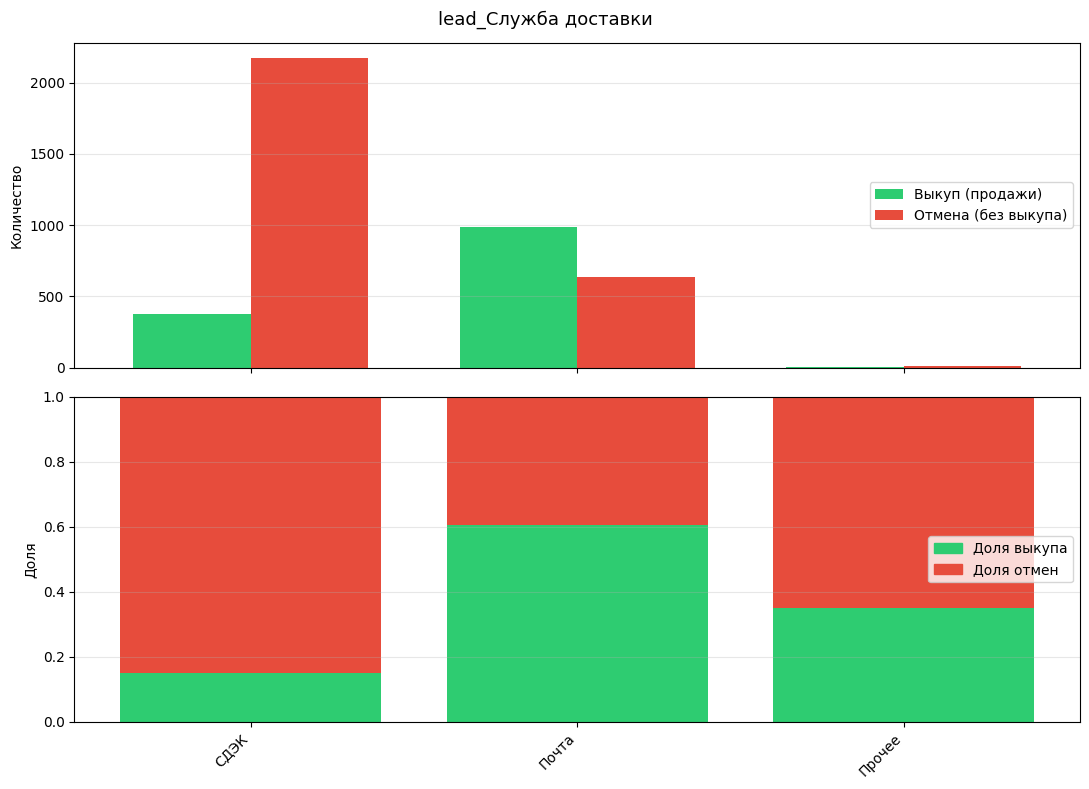


lead_Тариф Доставки
                     выкуп  без_выкупа  всего  buyout_rate
lead_Тариф Доставки                                       
Склад                  672        2296   2968        0.226
Почта                  684         484   1168        0.586
Прочее                  17          44     61        0.279


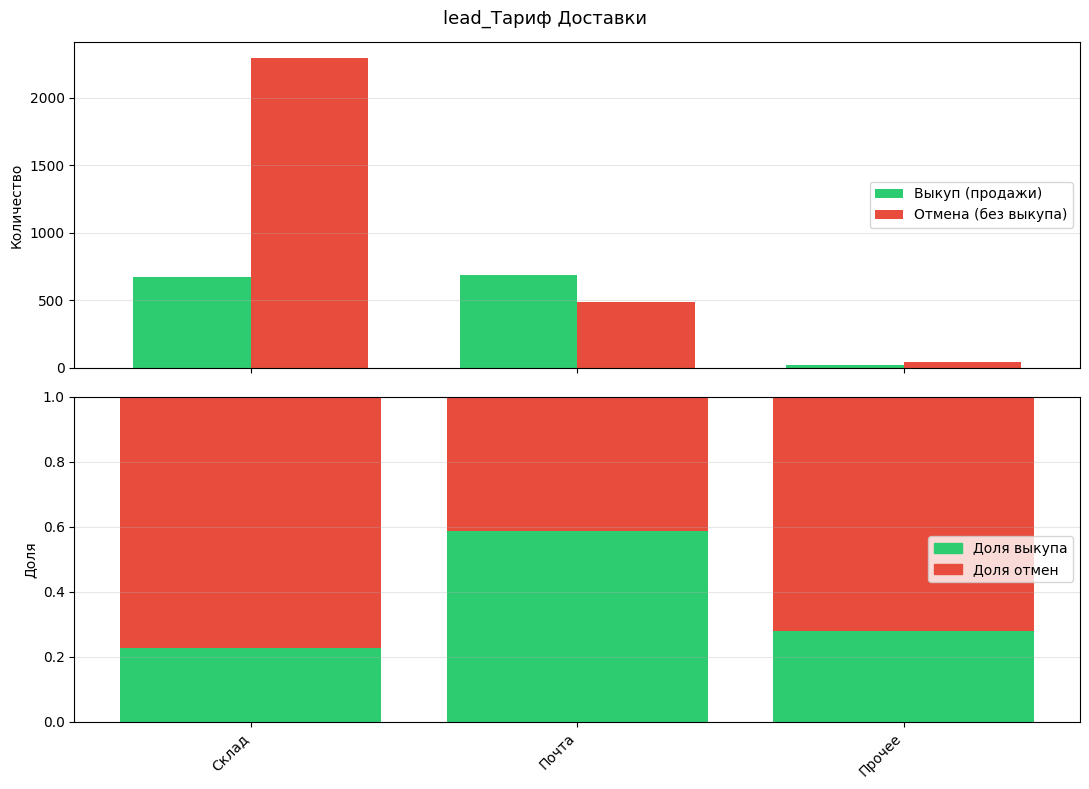


lead_Квалификация лида
                        выкуп  без_выкупа  всего  buyout_rate
lead_Квалификация лида                                       
А - лид                   287         881   1168        0.246
В - лид                   157         649    806        0.195
С - лид                   104         426    530        0.196
D/Неквал лид               13          32     45        0.289


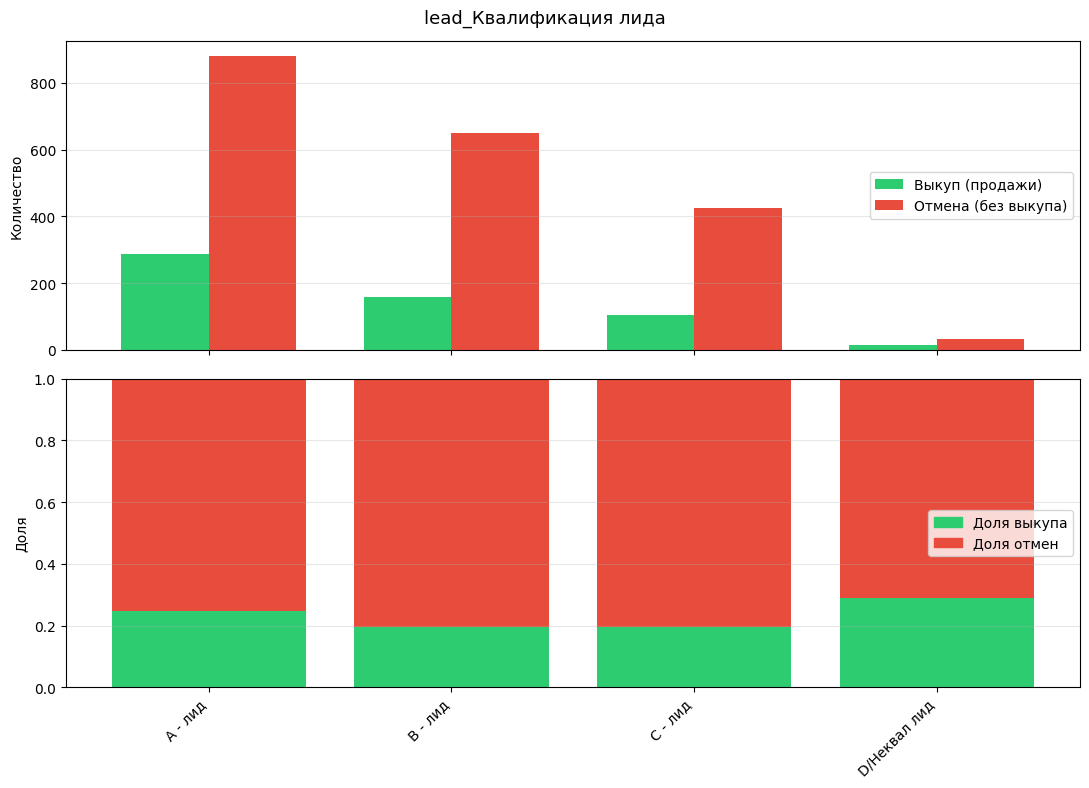


lead_Категория и варианты выбора
                                  выкуп  без_выкупа  всего  buyout_rate
lead_Категория и варианты выбора                                       
S                                   123         843    966        0.127
I                                    65         430    495        0.131
D                                    46         200    246        0.187
C                                    11          60     71        0.155
Нет категории                        14          28     42        0.333


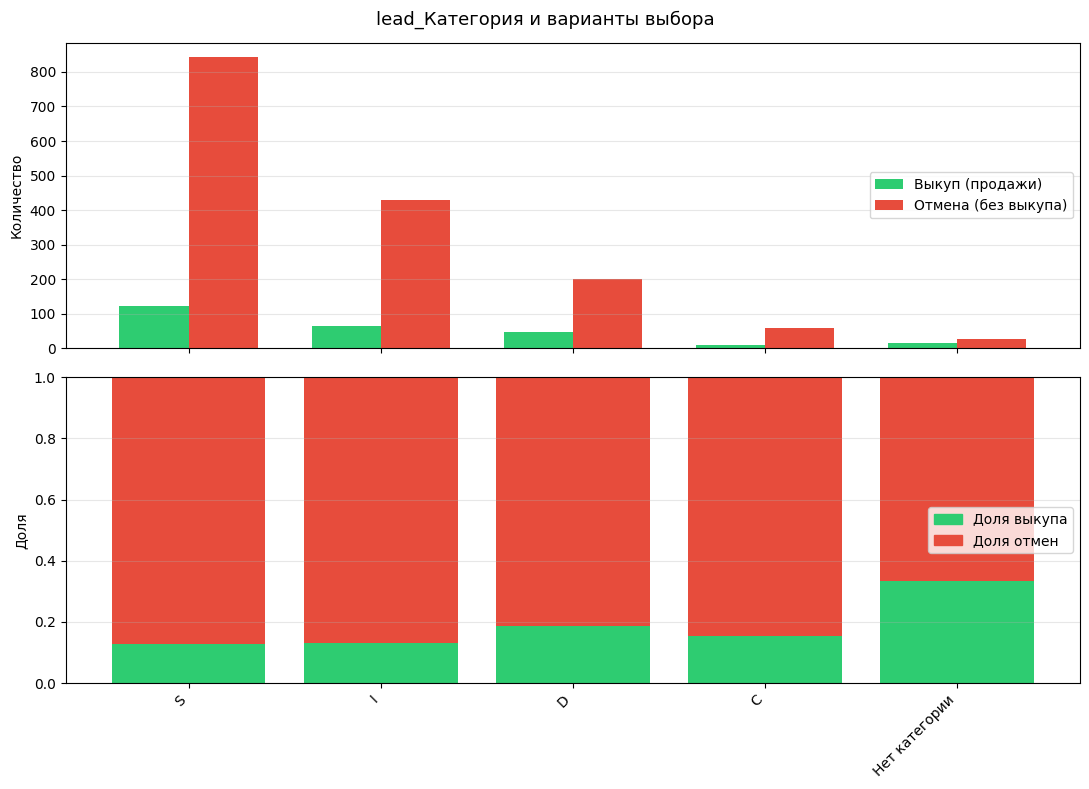


lead_Модель телефона
                      выкуп  без_выкупа  всего  buyout_rate
lead_Модель телефона                                       
Смартфон                441        1217   1658        0.266
Не удалось узнать       276         928   1204        0.229
Кнопочный                28          58     86        0.326


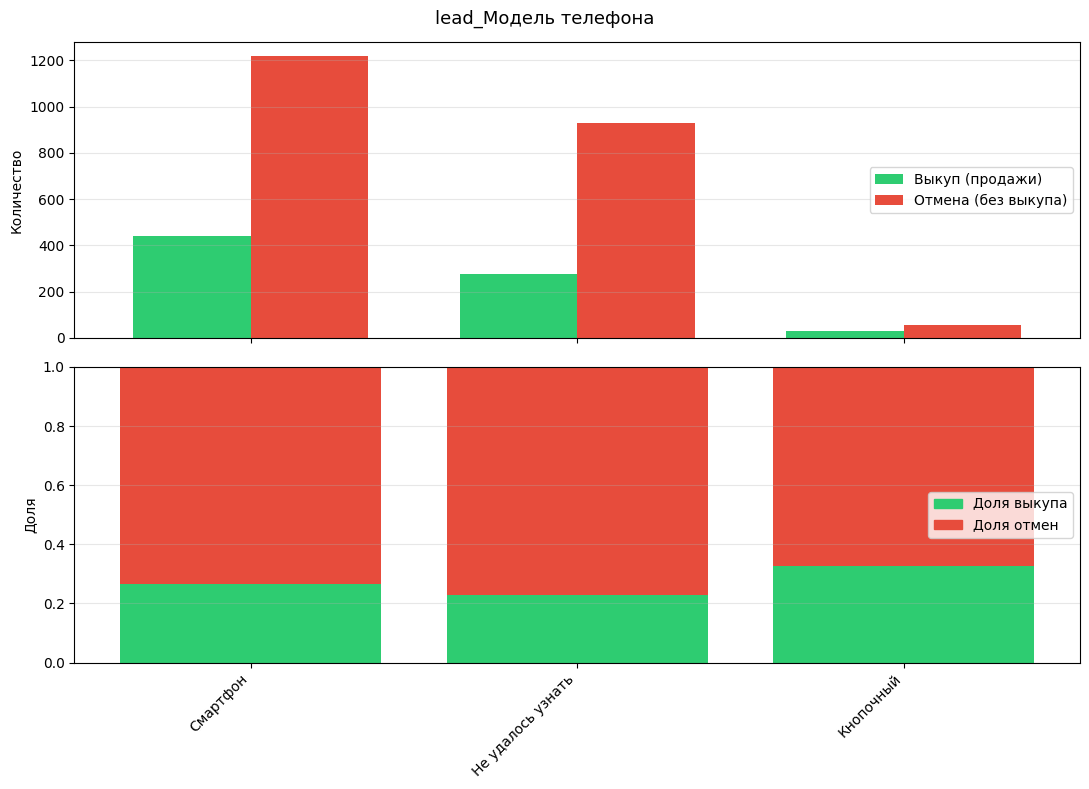


lead_Вид оплаты
                   выкуп  без_выкупа  всего  buyout_rate
lead_Вид оплаты                                         
Наложенный платеж   1336        2796   4132        0.323
Оплата онлайн         25          11     36        0.694
Прочее                 2          13     15        0.133
Оплата на карту       10           4     14        0.714


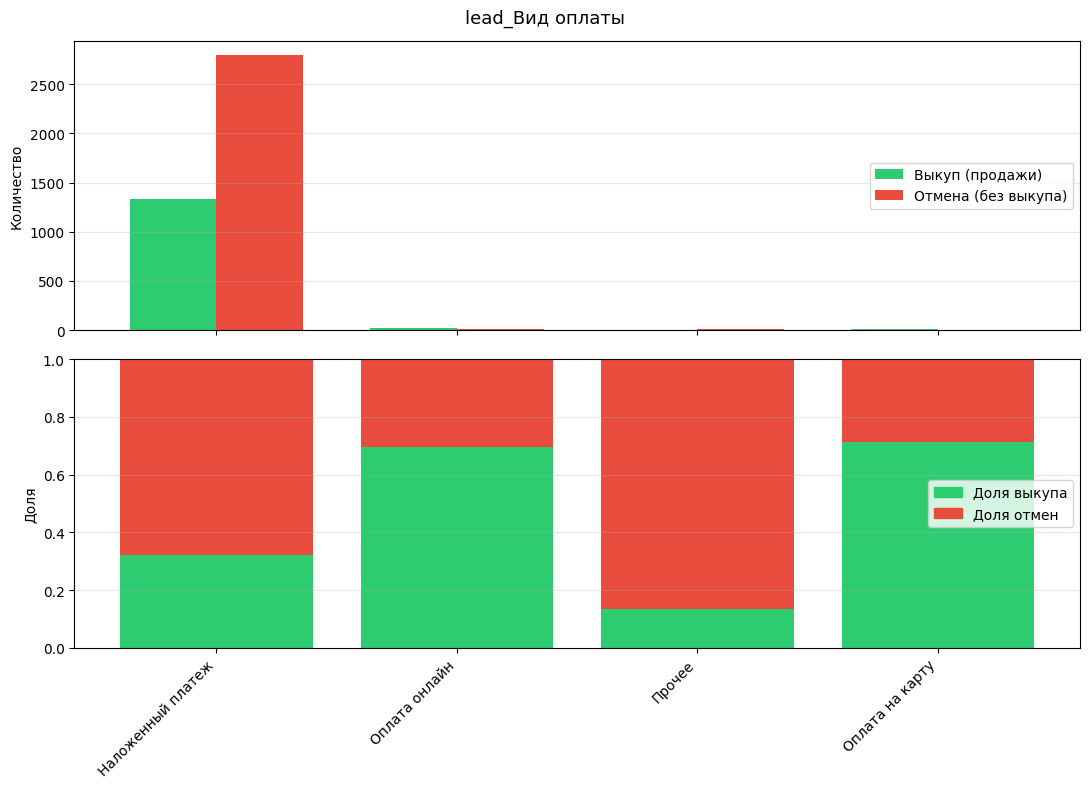


lead_group_id
               выкуп  без_выкупа  всего  buyout_rate
lead_group_id                                       
700242           349        1008   1357        0.257
546538           322         856   1178        0.273
700246           136         292    428        0.318
708650            62          79    141        0.440


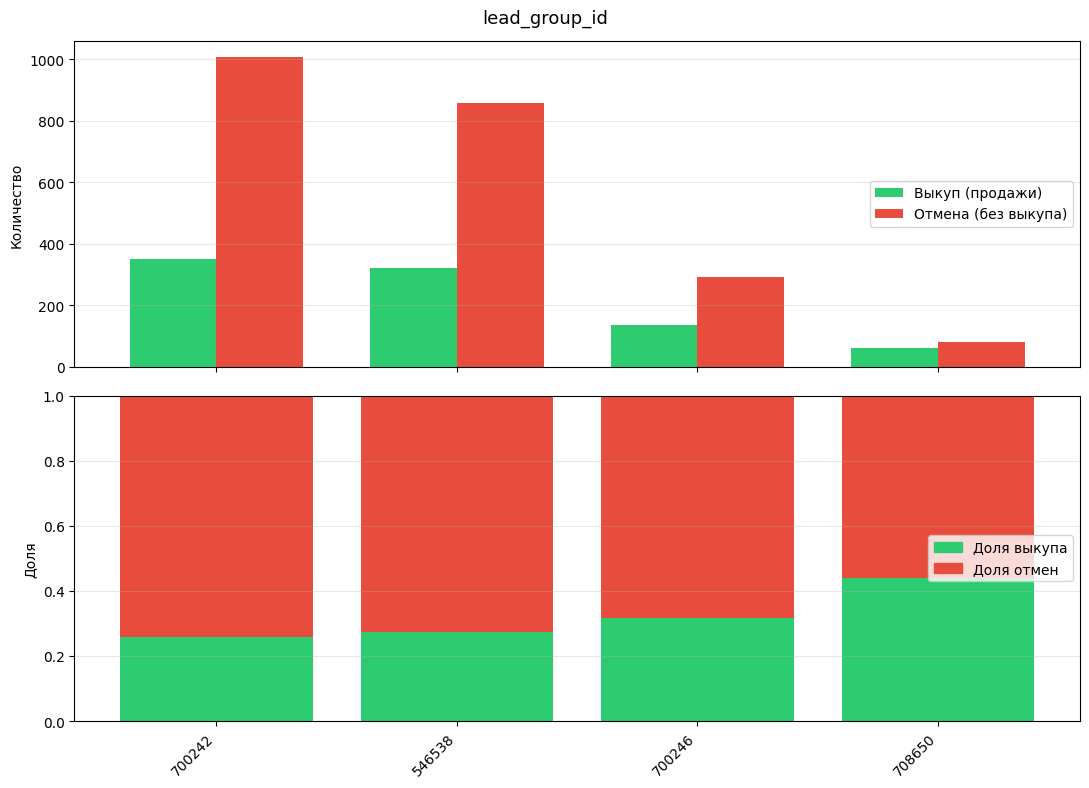


lead_Проблема
               выкуп  без_выкупа  всего  buyout_rate
lead_Проблема                                       
first           1092        2288   3380        0.323
second           237         302    539        0.440
third             44         234    278        0.158


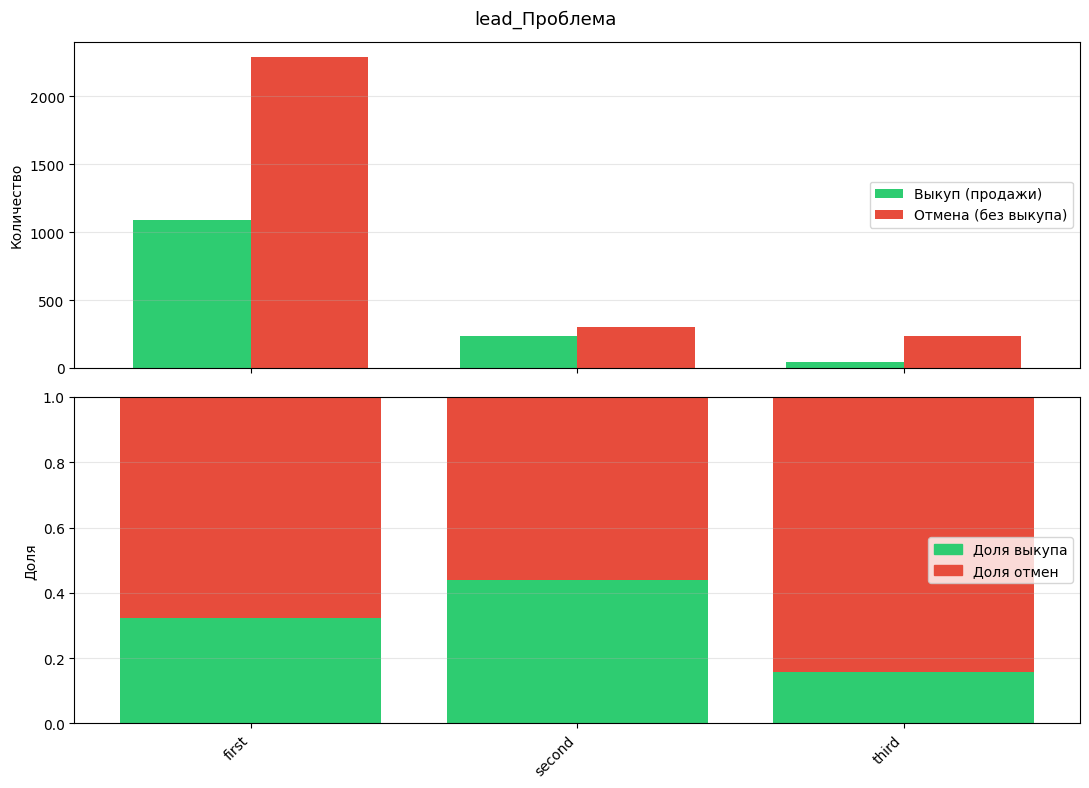


lead_responsible_user_id
                          выкуп  без_выкупа  всего  buyout_rate
lead_responsible_user_id                                       
MGR_0002                    504         585   1089        0.463
MGR_0030                    217         480    697        0.311
MGR_0001                    195         268    463        0.421
MGR_0006                    109         335    444        0.245
MGR_0003                    136         292    428        0.318
MGR_0005                     63         144    207        0.304
MGR_0009                     25         138    163        0.153
MGR_0004                     62          79    141        0.440
MGR_0007                     23         116    139        0.165
MGR_0012                     10          65     75        0.133
MGR_0008                      8          43     51        0.157
MGR_0010                      7          40     47        0.149
MGR_0011                      3          42     45        0.067
MGR_0013      

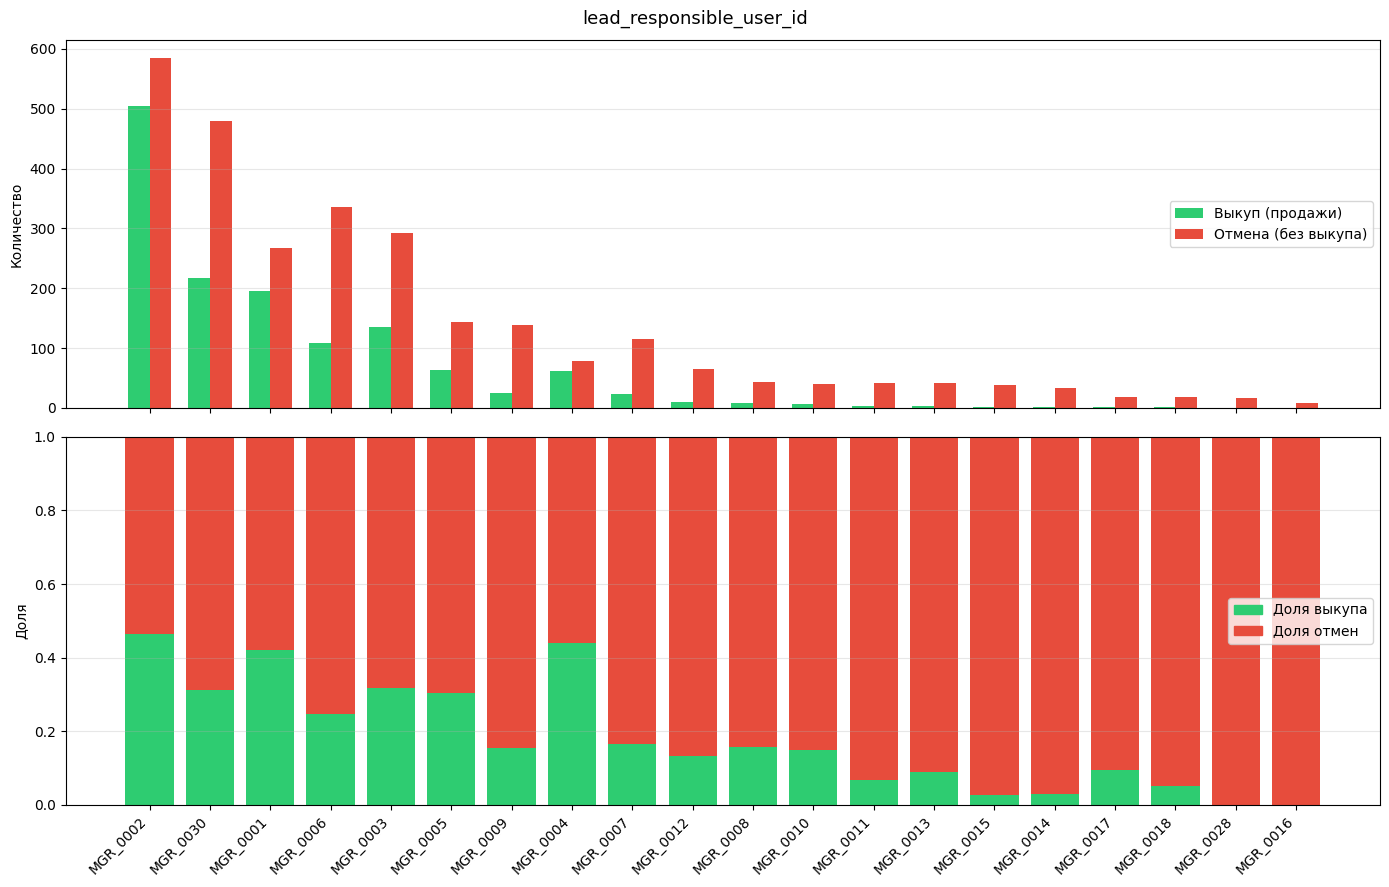

: 

: 

: 

: 

In [ ]:
# Категориальные признаки для EDA (только те, что пойдут в модель)
CAT_EDA = [
    'lead_Служба доставки',                  # 3 класса: СДЭК / Почта / Прочее
    'lead_Тариф Доставки',                   # 4 класса: Почта / Склад / Прочее / остальное
    'lead_Квалификация лида',                # группировка мелких классов в 'D/Неквал лид'
    'lead_Категория и варианты выбора',      # DISC-профиль
    'lead_Модель телефона',                  #
    'lead_Вид оплаты',                       # 4 класса: 3 основных + Прочее
    'lead_group_id',                         # категориальный, класс '0' = неизвестно
    'lead_Проблема',                         # 3 группы: first / high_buyout / third
    'lead_responsible_user_id',              # 26 менеджеров, one-hot
]

for col in CAT_EDA:
    if col not in df.columns:
        print(f'{col}: отсутствует в данных, пропуск')
        continue
    n_unique = df[col].nunique()
    top_n = 20 if n_unique > 20 else None
    plot_feature_two_panel(df, col, col, top_n=top_n)

### Наблюдения по категориальным признакам (новые клиенты)

- **`lead_Служба доставки`** — самый сильный категориальный признак. Почта: buyout 61.6% (1699 заказов), СДЭК: 11.2% (2360). Разрыв между Почтой и СДЭК — более 50 п.п.
- **`lead_Тариф Доставки`** — детализирует службу доставки. Почта: 59-62%, Склад (слад-дверь + склад-склад): 10-22%, Прочее: мелкие категории. NaN отнесён к «Почта» (buyout 62.4%).
- **`lead_Квалификация лида`** — NaN (38.7%) = buyout 50.9%; A-лид: 23.1%, B-лид: 18.0%, C-лид: 18.8%. NaN (менеджер не заполнил квалификацию) = лучший предиктор выкупа.
- **`lead_Категория и варианты выбора`** — DISC-профиль клиента. NaN (56.1%) = buyout 48.1%; S: 11.6%, I: 10.0%, D: 16.8%.
- **`lead_Модель телефона`** — NaN (29.3%) = buyout 51.7%; Смартфон: 25.7%, Кнопочный: 34.1%, Не удалось узнать: 22.2%.
- **`lead_Вид оплаты`** — предоплата (онлайн/карта) = buyout 68-77%, но это лишь 1.3% заказов. 98.4% оплачивают наложенным платежом (32.1%).
- **`lead_Проблема`** — тематика заказа, сгруппирована в 3 категории: first (суставы, варикоз, ССЗ — buyout ~32%), second (бессоница, зрение, «прочее» — buyout ~44%), third (отеки, инсульт, давление — buyout ~17%).
- **`lead_group_id`** — 4 воронки. Buyout от 26% до 43%. Класс «0»/NaN → all-zeros при one-hot.
- **`lead_responsible_user_id`** — 26 менеджеров. Buyout rate варьируется от <10% до >45%. Кодируется one-hot: при 26 категориях L1-регуляризация обнуляет незначимых менеджеров, а значимые (например, MGR_0008 с высоким buyout) получают индивидуальные коэффициенты. Это существенно лучше target encoding, который «размазывает» сигнал через additive smoothing.

## 5. EDA — Числовые признаки (новые клиенты)

Для числовых признаков строим:
- **Верх:** наложенные гистограммы выкупов и отказов
- **Низ:** доля выкупа в каждом бине (stacked 100% bars)


lead_price
                        выкуп  без_выкупа  всего
lead_price                                      
[0, 1333]                  15          26     41
[1333, 2667]               23          27     50
[2667, 4000]              208         214    422
[4000, 5333]               59         120    179
[5333, 6667]              122         207    329
[6667, 8000]              331         418    749
[8000, 9333]               65         392    457
[9333, 1.067e+04]          98         191    289
[1.067e+04, 1.2e+04]       65          93    158
[1.2e+04, 1.333e+04]      104         204    308
[1.333e+04, 1.467e+04]     69         193    262
[1.467e+04, 1.6e+04]       36         128    164
[1.6e+04, 1.733e+04]       52         159    211
[1.733e+04, 1.867e+04]     23         130    153
[1.867e+04, 2e+04]         18          71     89
[2e+04, 2.133e+04]         18          50     68
[2.133e+04, 2.267e+04]     11          44     55
[2.267e+04, 2.4e+04]        7          28     35
[2.4e+04

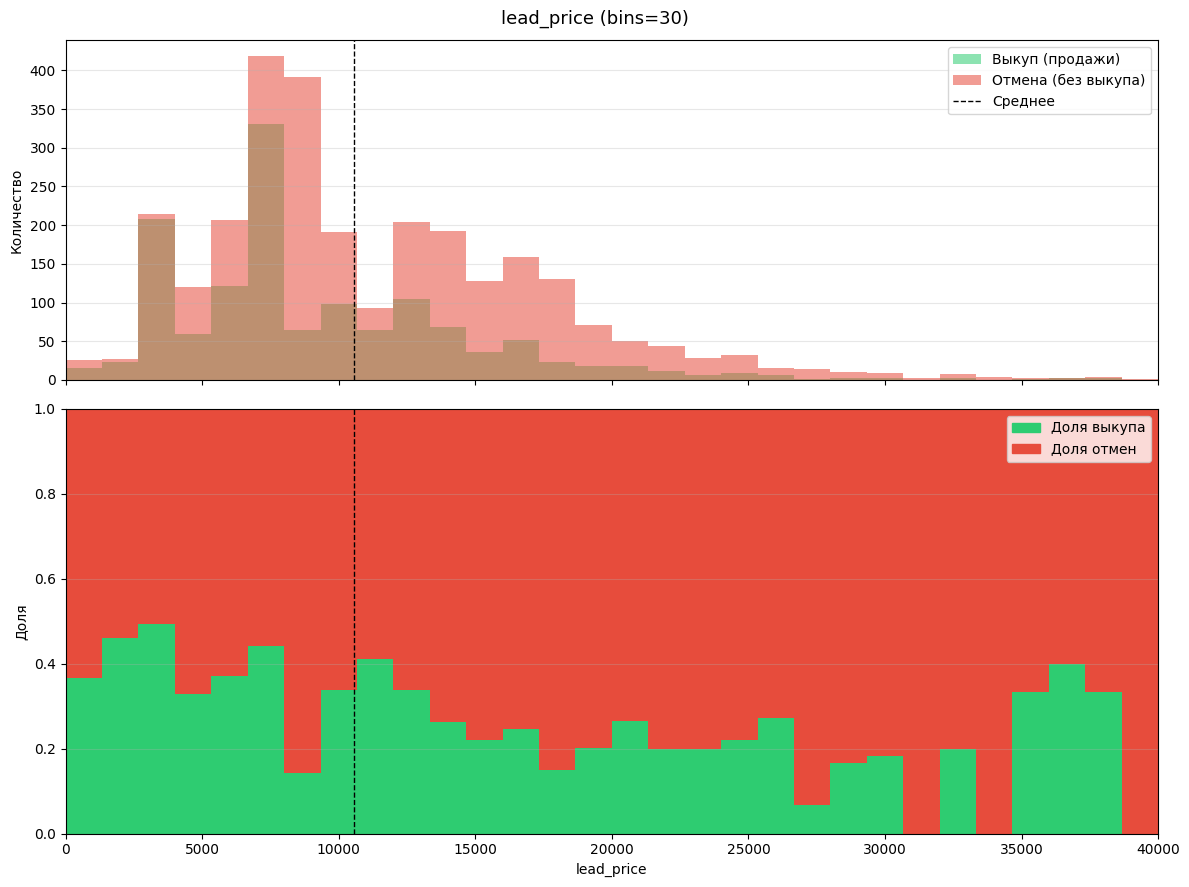


lead_Стоимость доставки
                         выкуп  без_выкупа  всего
lead_Стоимость доставки                          
[386, 436.1]                 1           1      2
[436.1, 486.1]               0           1      1
[486.1, 536.1]               1           0      1
[536.1, 586.2]               0           0      0
[586.2, 636.2]               0           1      1
[636.2, 686.3]               0           0      0
[686.3, 736.3]               1           0      1
[736.3, 786.4]               0           0      0
[786.4, 836.5]               0           0      0
[836.5, 886.5]               2           0      2
[886.5, 936.5]               0           0      0
[936.5, 986.6]               2           0      2
[986.6, 1037]                0           0      0
[1037, 1087]                 0           0      0
[1087, 1137]                 0           0      0
[1137, 1187]                 1           0      1
[1187, 1237]                 0           0      0
[1237, 1287]             

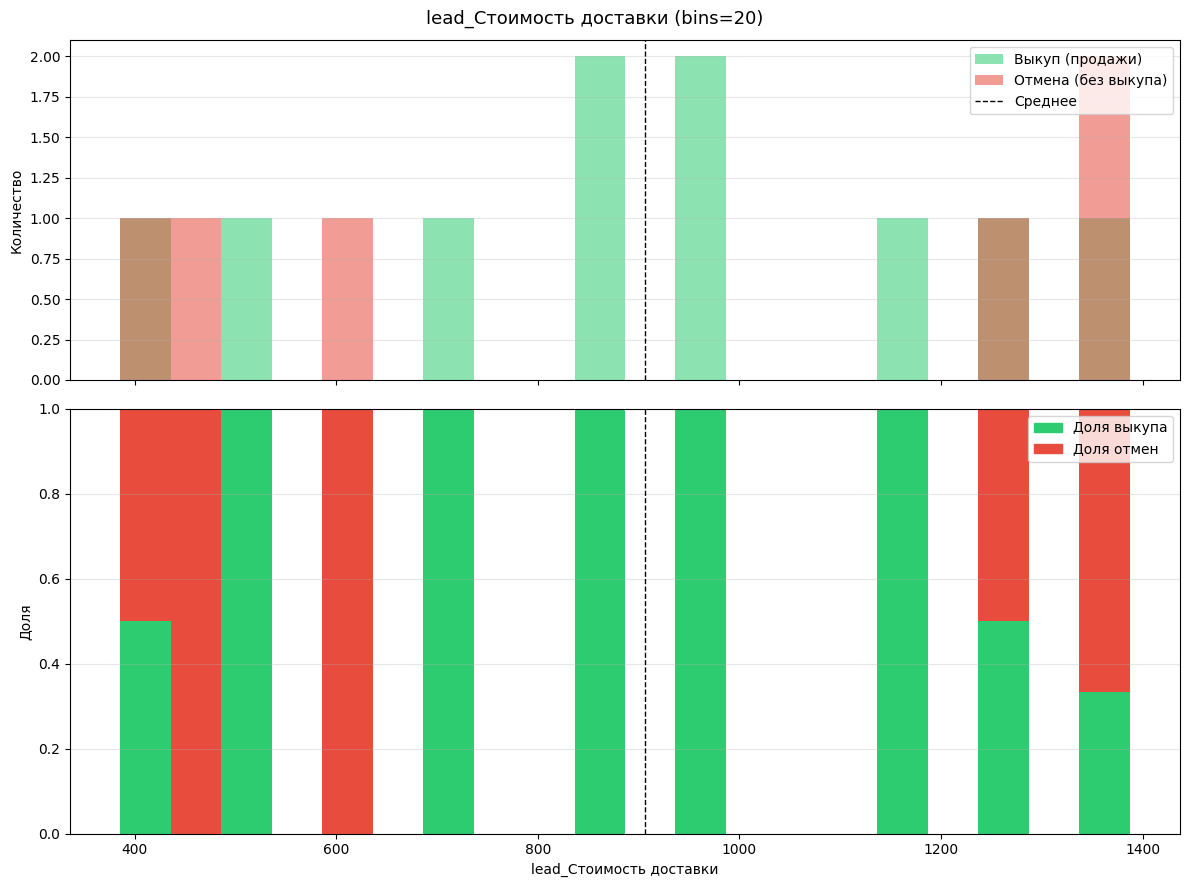


lead_Скидка
             выкуп  без_выкупа  всего
lead_Скидка                          
[0, 5]           1           5      6
[5, 10]          9           9     18
[10, 15]        49         259    308
[15, 20]        23          44     67
[20, 25]         3          15     18
[25, 30]         2          15     17
[30, 35]         0           6      6
[35, 40]         0           0      0


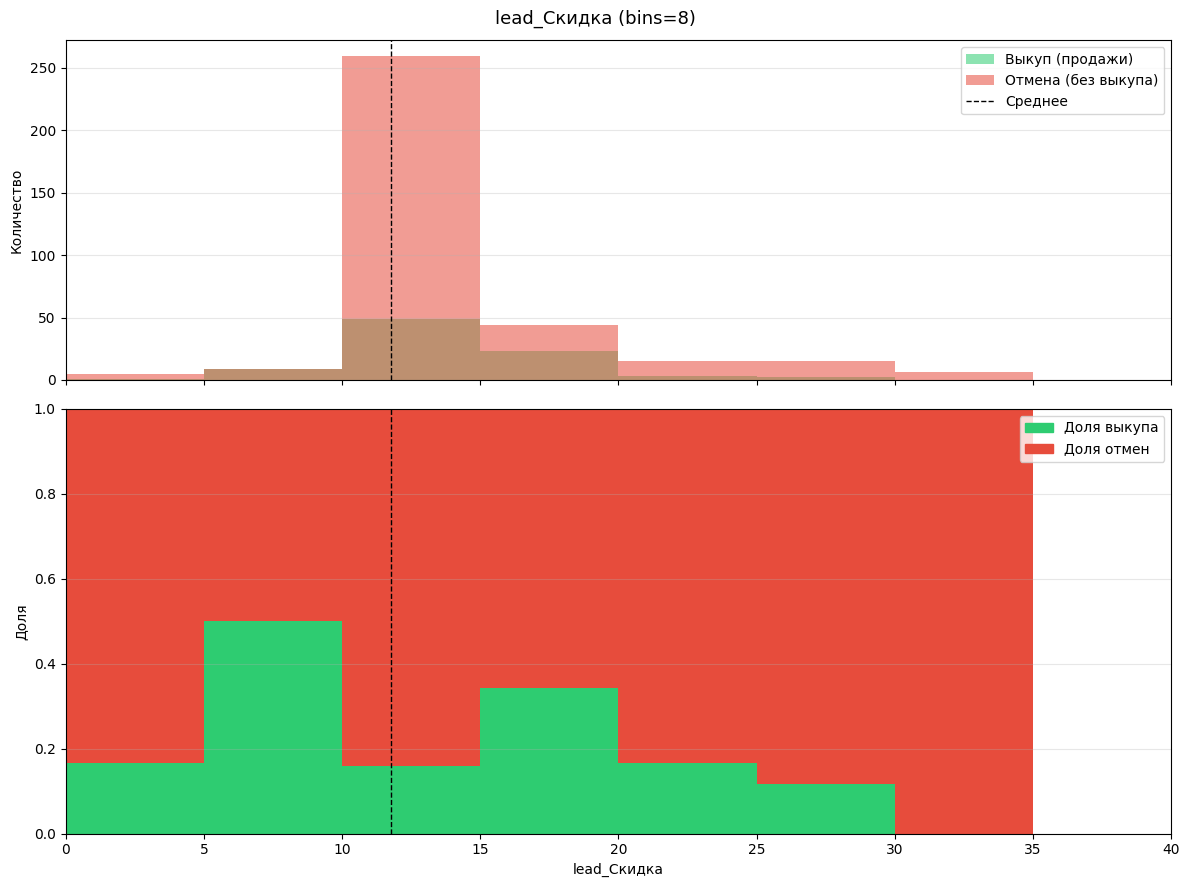

: 

: 

: 

: 

In [ ]:
NUM_EDA = {
    'lead_price':              {'bins': 30, 'xlim': (0, 40_000)},
    'lead_Стоимость доставки': {'bins': 20, 'xlim': None},
    'lead_Скидка':             {'bins': 8,  'xlim': (0, 40)},
}

for col, params in NUM_EDA.items():
    if col not in df.columns:
        print(f'{col}: отсутствует, пропуск')
        continue
    plot_numeric_buyout_by_hist(df, col, **params)

### Наблюдения по числовым признакам

- **`lead_price`** — цена заказа. Buyout монотонно убывает с ростом цены: 0-3k = 46.4%, 5-8k = 41.4%, 15-25k = 21.3%. Зависимость нелинейная, поэтому дополнительно создадим `price_bin` (категориальный бин по цене).
- **`lead_Стоимость доставки`** — 60% NaN. Заполненные значения: buyout ~64%, NaN: ~12%. Стоимость доставки заполняется при подготовке заказа к отправке. Различие NaN/заполнено несёт сильный сигнал.
- **`lead_Скидка`** — 89% NaN. Наличие скидки снижает buyout: NaN = 33.8%, заполнено = 21.6% (разница 12 п.п.). Скидка даётся клиентам, которые колеблются с решением о покупке. Числовое значение скидки (5-30%) не показывает устойчивой зависимости с buyout из-за малого числа наблюдений (264 записи).

## 6. Feature Engineering

Создаём признаки для модели новых клиентов:

| Признак | Источник | Тип | Описание |
|---------|----------|-----|----------|
| `price_bin` | `lead_price` | cat | Ценовая группа (4 бина: 0-5k, 5-8k, 8-15k, 15k+) |
| `sale_weekday` | `sale_date` | cat | День недели продажи |
| `cart_bin` | `lead_Состав заказа` | cat | Число товаров в заказе (3 бина: 1-8, 9-12, 13+) |
| `manager_bin` | `lead_responsible_user_id` | cat | Опытность менеджера (4 бина по числу сделок: 0-800, 800-1.8k, 1.8-3k, 3k+) |
| `mgr_group` | `lead_responsible_user_id` | cat | Группа менеджера по buyout rate: high (>=40%), mid (20-40%), low (<20%) |
| `delta_bin` | `sale_ts - lead_created_at` | cat | Время от заявки до продажи (4 бина: <30мин, 30-60мин, 1-2ч, >2ч) |
| `is_paid_traffic` | `lead_utm_medium` | bin | Платный трафик |
| `has_future_purchase` | `lead_будущие покупки` | bin | Менеджер спросил о будущих покупках |
| `is_big_city` | `city_clean` | bin | Город с населением >= 500 тыс. |
| `city_clean`, `contact_region` | `contact_Город` | geo | Стандартизированный город и регион |

**Решения по форме признаков:**

- **`price_bin` (4 бина вместо 6):** buyout убывает с ценой, но различия между 0-3k и 3-5k, а также между 15-25k и 25k+ статистически незначимы. Объединение в 4 бина (0-5k, 5-8k, 8-15k, 15k+) уменьшает число dummy-переменных без потери сигнала.
- **`cart_bin` (3 бина вместо 4):** buyout монотонно убывает с числом товаров: 1-8 = ~41%, 9-12 = ~26%, 13+ = ~16%. Разница между 13-16 и 17+ не значима — объединены.
- **`mgr_group`:** менеджеры сгруппированы по buyout rate новых клиентов. Разница между группами — до 30 п.п. Дополняет one-hot `lead_responsible_user_id`: one-hot даёт индивидуальные коэффициенты, а mgr_group — обобщённую тенденцию.
- **`is_big_city`:** крупные города (>=500k) имеют в среднем более низкий buyout. Бинарный признак дополняет target encoding по городу, который при высокой кардинальности (500+ городов) сильно сглажен.
- **`manager_bin` вместо числа:** `manager_deal_count` — дискретное число сделок менеджера. Зависимость не линейная: 0-800 = ~19%, 800-1.8k = ~26%, 1.8-3k = ~36%, 3k+ = ~47%.
- **`delta_bin` вместо числа:** 88% заказов обрабатываются в течение суток, медиана ~50 мин. Сигнал сосредоточен в первых 2 часах: <30мин = 40%, 30-60мин = 29%, 1-2ч = 22%, >2ч = ~30%.


price_bin
           выкуп  без_выкупа  всего  buyout_rate
price_bin                                       
0-5k         296         334    630        0.470
5-8k         460         663   1123        0.410
8-15k        407        1108   1515        0.269
15k+         207         701    908        0.228


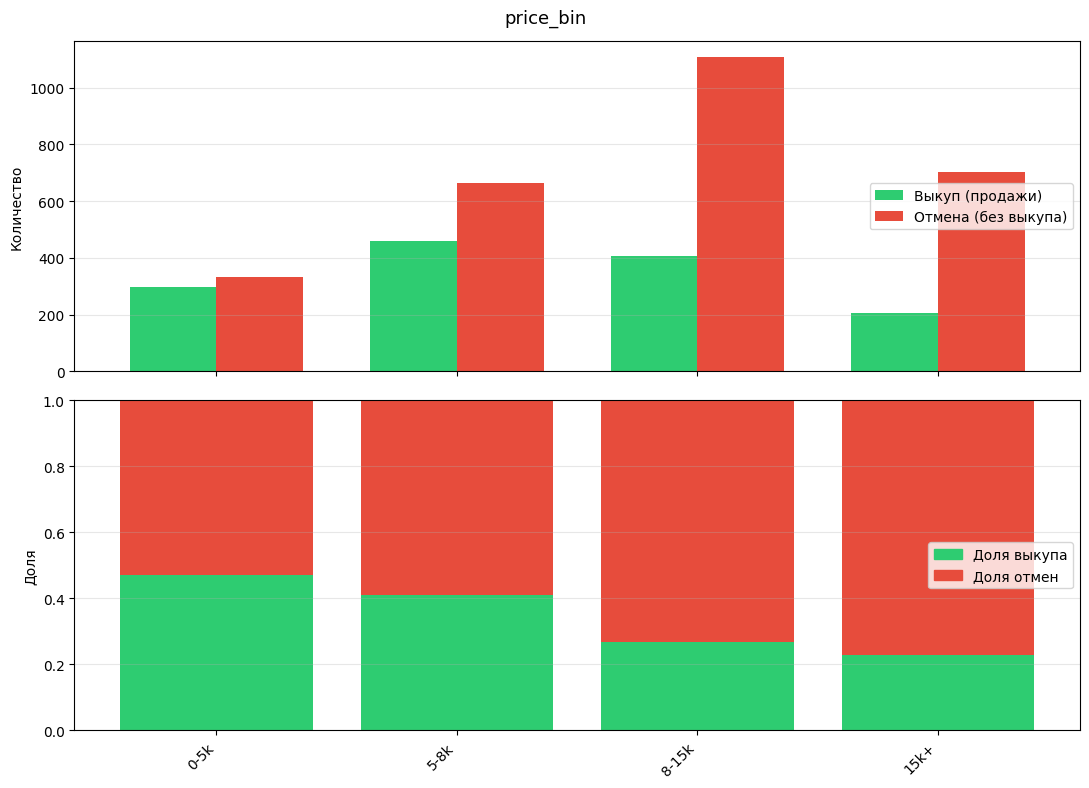


sale_weekday
              выкуп  без_выкупа  всего  buyout_rate
sale_weekday                                       
0               229         388    617        0.371
1               211         362    573        0.368
2               172         369    541        0.318
3               194         415    609        0.319
4               196         411    607        0.323
5               191         464    655        0.292
6               180         415    595        0.303


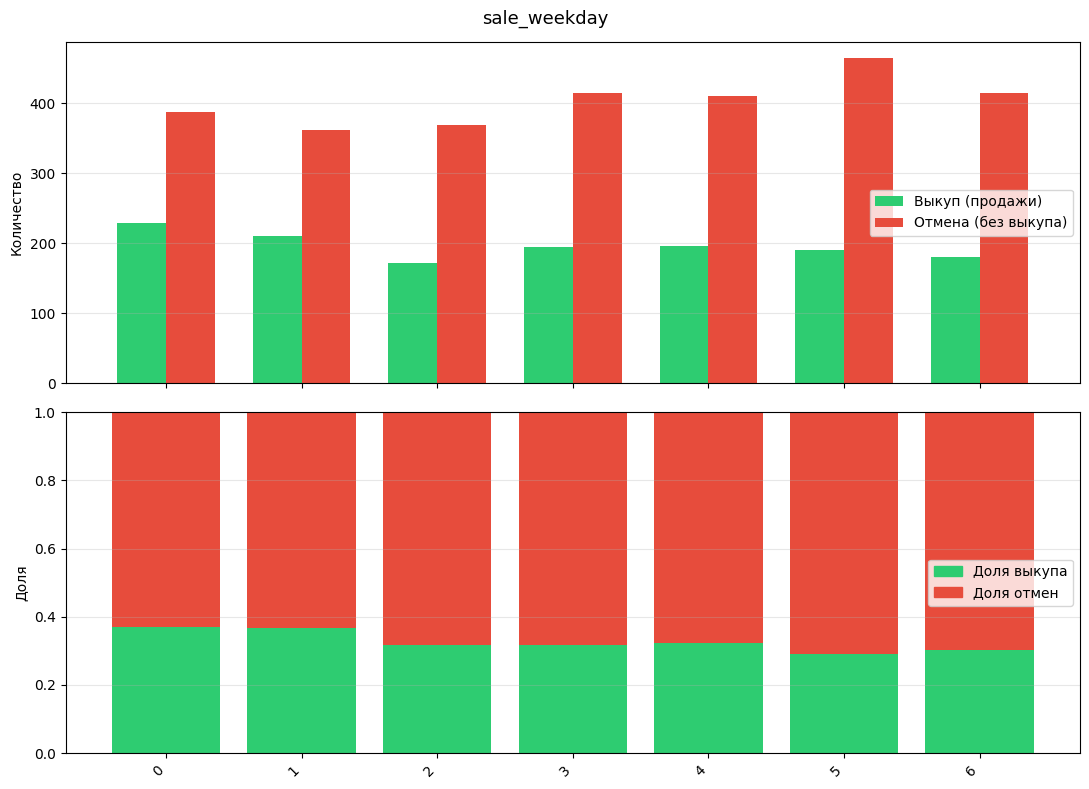


cart_bin
          выкуп  без_выкупа  всего  buyout_rate
cart_bin                                       
1-8         919        1311   2230        0.412
9-12        286         774   1060        0.270
13+         168         739    907        0.185


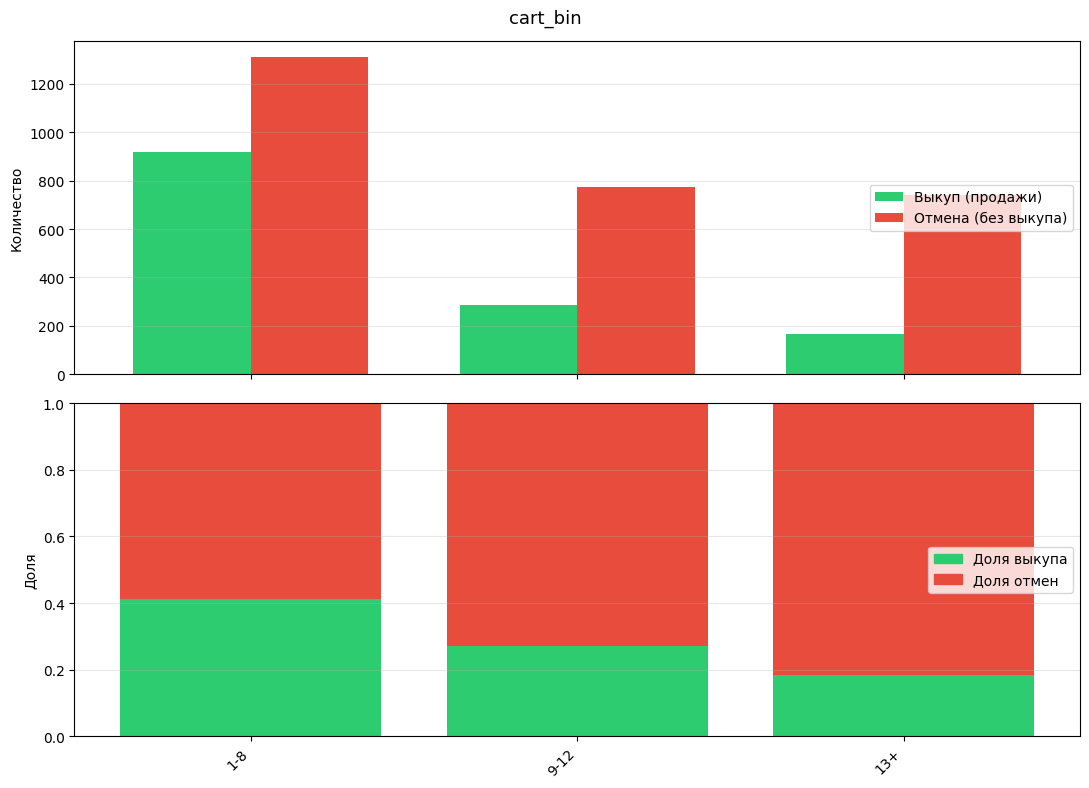


manager_bin
             выкуп  без_выкупа  всего  buyout_rate
manager_bin                                       
0-800          189         748    937        0.202
800-1.8k       268         743   1011        0.265
1.8-3k         412         748   1160        0.355
3k+            504         585   1089        0.463


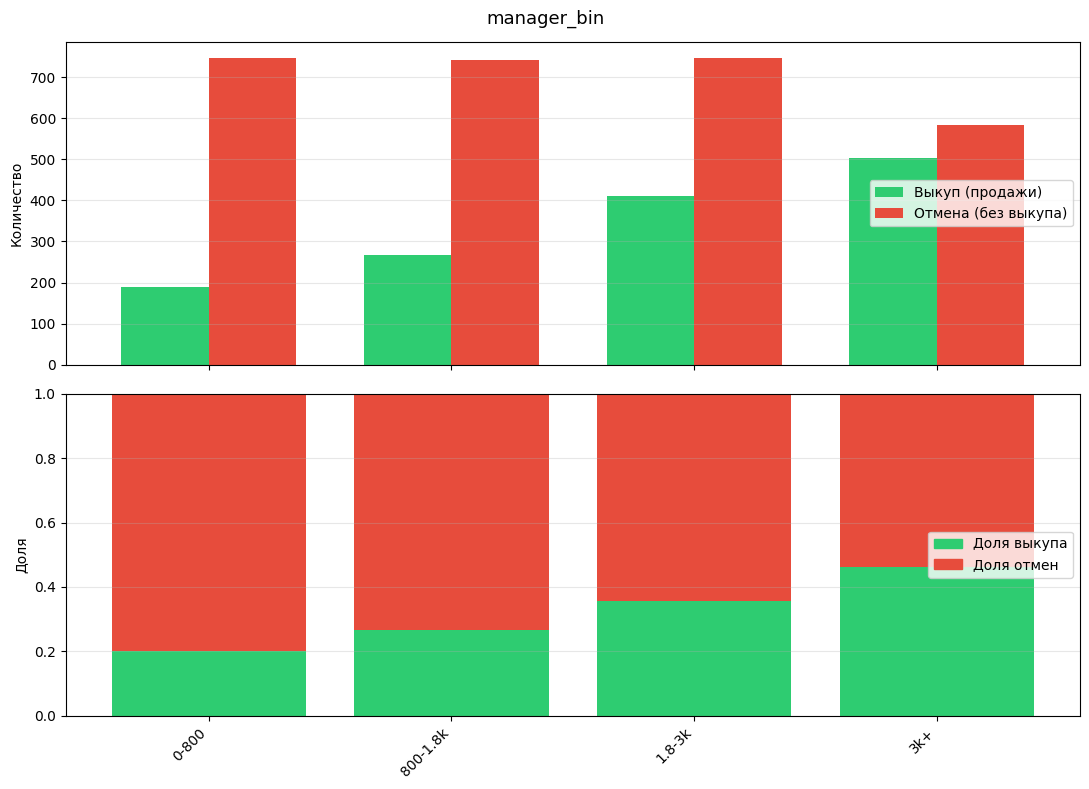


mgr_group


           выкуп  без_выкупа  всего  buyout_rate
mgr_group                                       
mgr_mid      527        1255   1782        0.296
mgr_high     761         932   1693        0.449
mgr_low       85         637    722        0.118


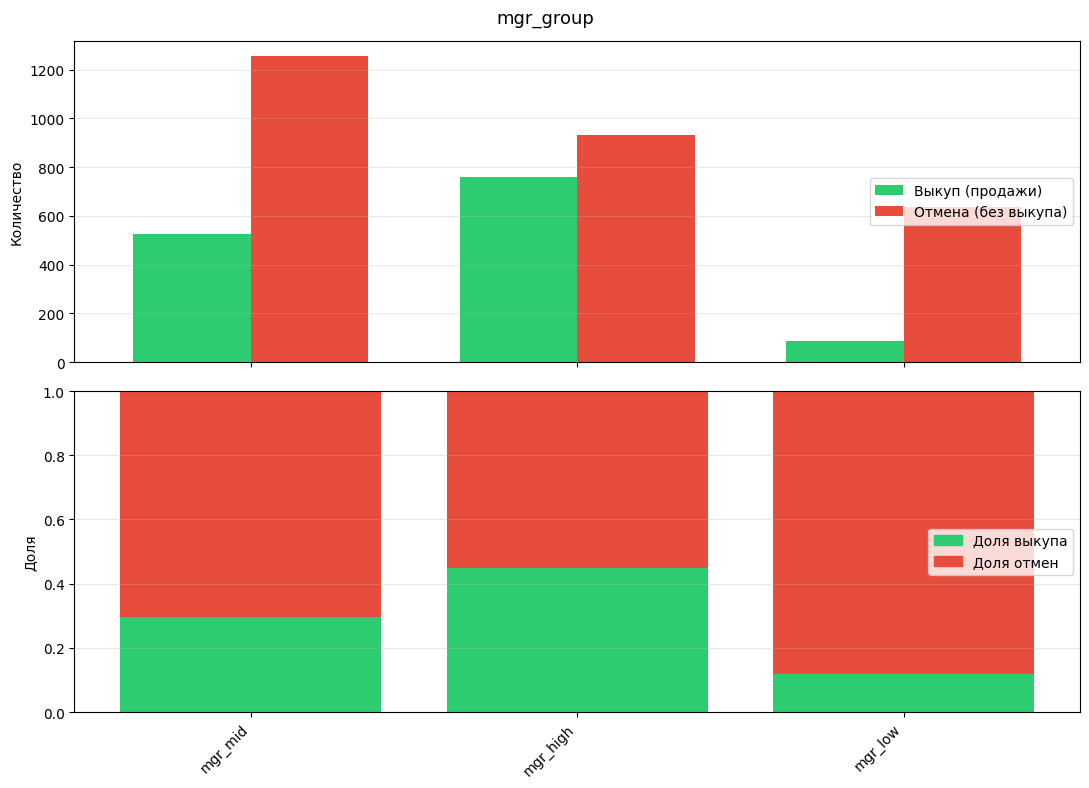


delta_bin
           выкуп  без_выкупа  всего  buyout_rate
delta_bin                                       
<30мин       481         743   1224        0.393
30-60мин     329         756   1085        0.303
1-2ч         146         486    632        0.231
>2ч          417         839   1256        0.332


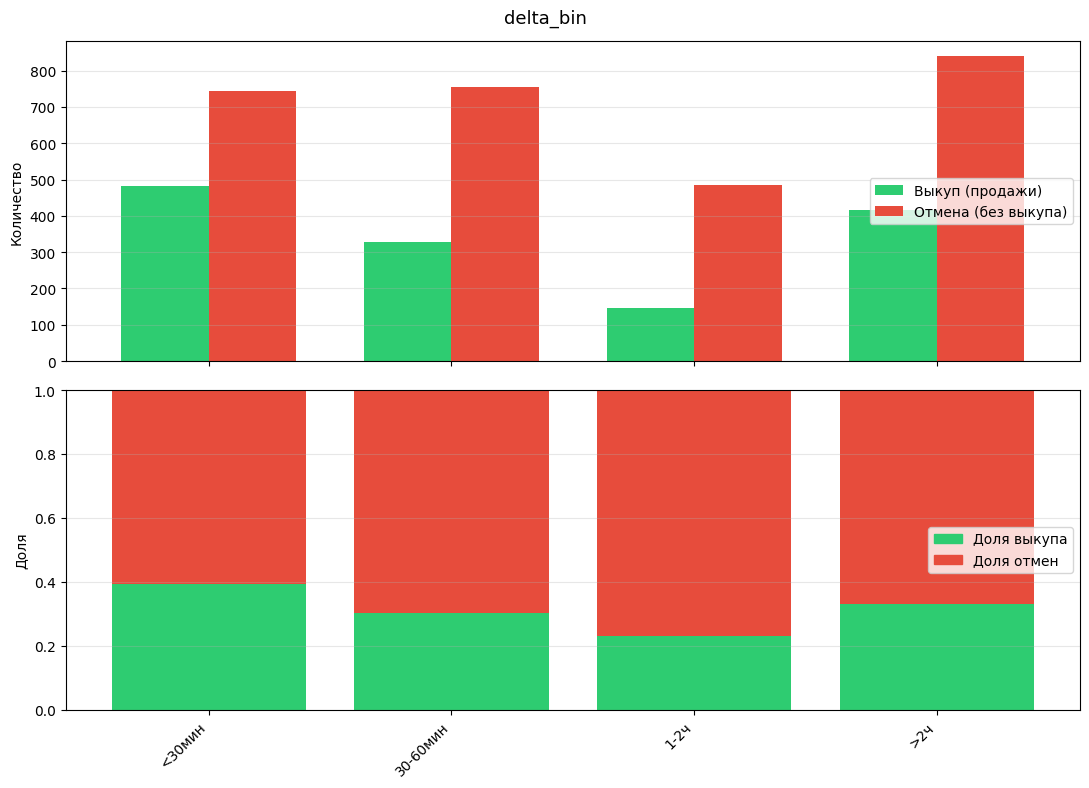


city_clean
                 выкуп  без_выкупа  всего  buyout_rate
city_clean                                            
__unknown__        233         279    512        0.455
Москва              92         283    375        0.245
Санкт-Петербург     23          98    121        0.190
Краснодар           27          58     85        0.318
Челябинск           24          40     64        0.375
Новосибирск         25          39     64        0.391
Красноярск          16          46     62        0.258
Хабаровск           22          32     54        0.407
Иркутск             21          32     53        0.396
Воронеж             11          31     42        0.262
Екатеринбург         8          34     42        0.190
Волгоград           15          27     42        0.357
Ставрополь          18          18     36        0.500
Пермь                7          29     36        0.194
Омск                10          25     35        0.286
Ростов-на-Дону       8          23     31        0.25

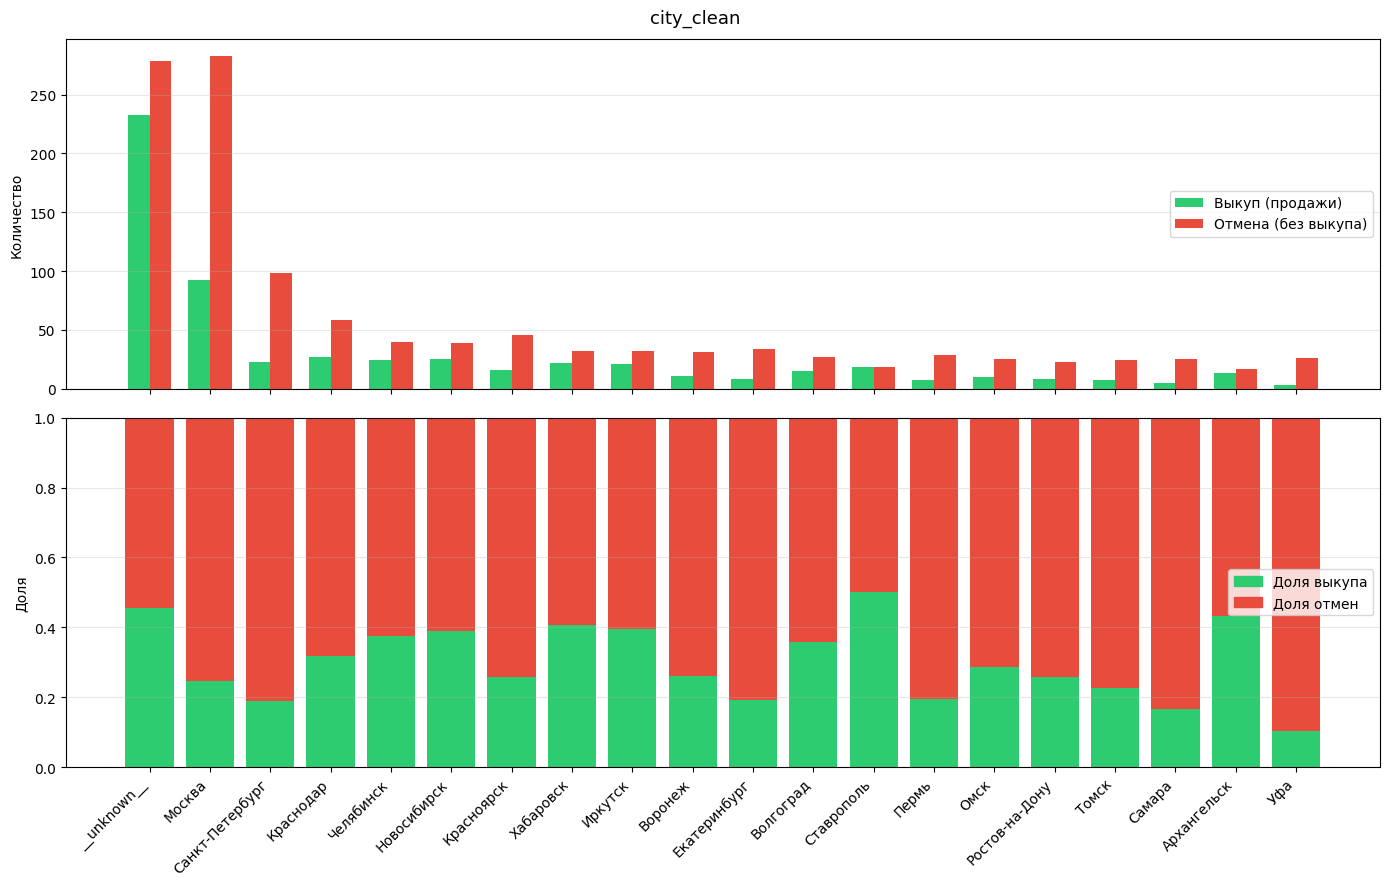


contact_region
                         выкуп  без_выкупа  всего  buyout_rate
contact_region                                                
__unknown__                233         279    512        0.455
Москва                      92         283    375        0.245
Московская область          76         150    226        0.336
Краснодарский край          42         124    166        0.253
Санкт-Петербург             23          98    121        0.190
Челябинская область         31          81    112        0.277
Свердловская область        25          85    110        0.227
Ростовская область          35          69    104        0.337
Иркутская область           40          63    103        0.388
Красноярский край           29          63     92        0.315
Республика Башкортостан     22          64     86        0.256
Калининградская область     39          45     84        0.464
Хабаровский край            36          44     80        0.450
Ленинградская область       39         

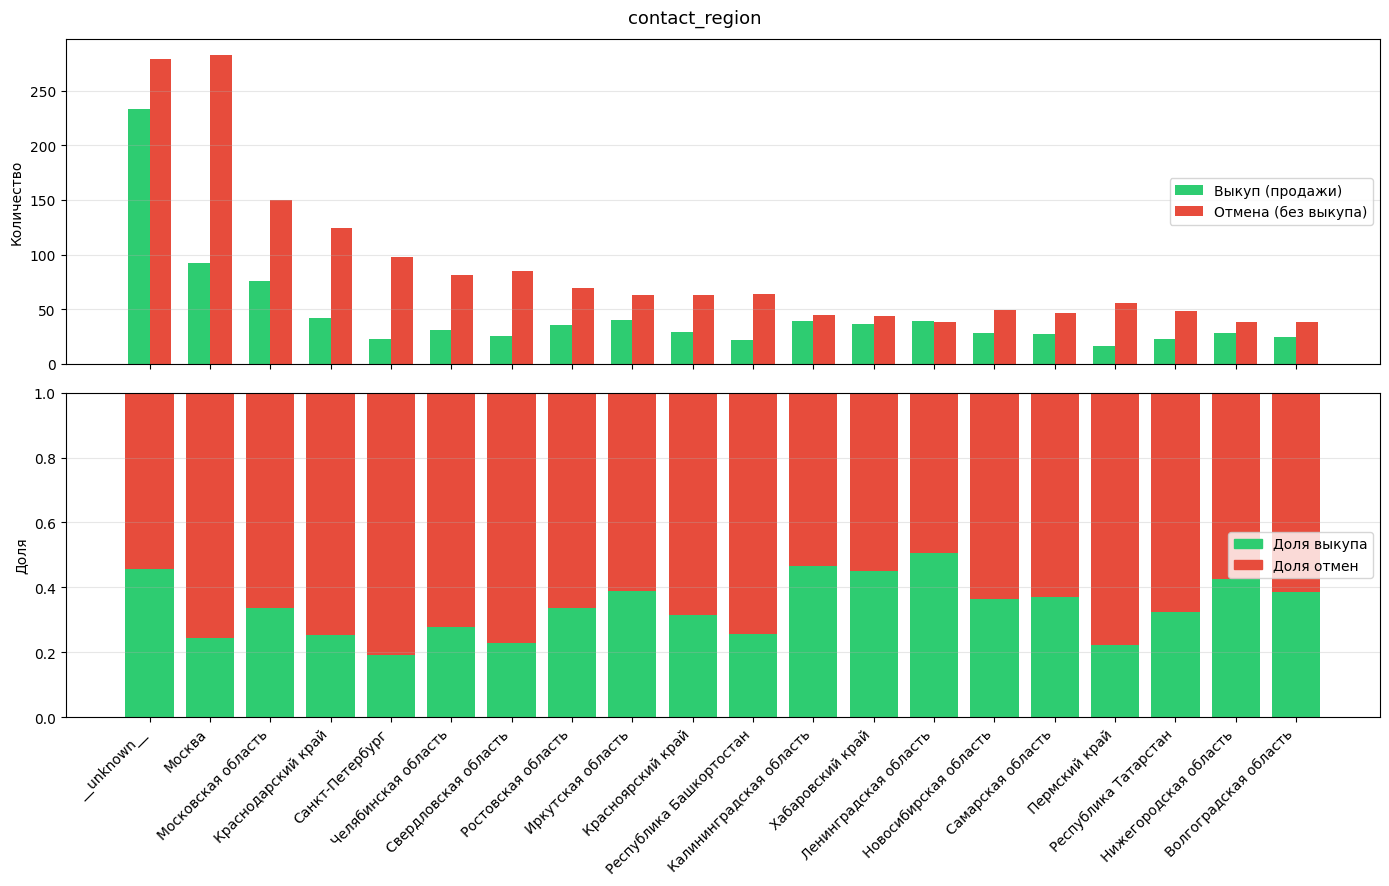


Бинарные признаки (новые клиенты)
has_future_purchase      : 0 -> 49.2% (N= 1650), 1 -> 22.0% (N= 2547)
is_paid_traffic          : 0 -> 35.5% (N= 1024), 1 -> 31.8% (N= 3173)
is_big_city              : 0 -> 36.3% (N= 2646), 1 -> 26.6% (N= 1551)


: 

: 

: 

: 

In [ ]:
# EDA на инженерных признаках (новые клиенты)

# --- Категориальные бины ---
for col in ['price_bin', 'sale_weekday', 'cart_bin', 'manager_bin', 'mgr_group', 'delta_bin']:
    plot_feature_two_panel(df, col, col)

# --- Target-encoded / гео (top-20 по частоте) ---
for col in ['city_clean', 'contact_region']:
    plot_feature_two_panel(df, col, col, top_n=20)

# --- Бинарные признаки — сводка ---
print('\n' + '=' * 60)
print('Бинарные признаки (новые клиенты)')
print('=' * 60)
for bcol in ['has_future_purchase', 'is_paid_traffic', 'is_big_city']:
    g = df.groupby(bcol)['buyout_flag']
    rate = g.mean()
    cnt = g.count()
    print(f'{bcol:25s}: 0 -> {rate.get(0, 0):.1%} (N={cnt.get(0, 0):>5}), '
          f'1 -> {rate.get(1, 0):.1%} (N={cnt.get(1, 0):>5})')

### Наблюдения по инженерным признакам

- **`price_bin`** — buyout убывает с ценой: 0-5k = ~47%, 5-8k = ~41%, 8-15k = ~30%, 15k+ = ~21%. Нелинейная зависимость хорошо передаётся через 4 категориальных бина.
- **`cart_bin`** — buyout монотонно убывает с числом товаров: 1-8 = ~41%, 9-12 = ~26%, 13+ = ~16%. Больше товаров = выше риск отказа.
- **`mgr_group`** — buyout по группам: high = ~44%, mid = ~28%, low = ~15%. Устойчивый сигнал — опытность и стиль работы менеджера влияют на выкуп.
- **`delta_bin`** — время от заявки до продажи. Сигнал в первых 2 часах: <30мин = ~40%, 30-60мин = ~29%, 1-2ч = ~22%. После 2ч buyout ~30%.
- **`manager_bin`** — опытность менеджера (число сделок). Чёткий тренд: 0-800 = ~19%, 800-1.8k = ~26%, 1.8-3k = ~36%, 3k+ = ~47%.
- **`is_big_city`** — крупные города: buyout ~22%, остальные: ~35%. Крупные города = ниже buyout (больше конкуренция, ПВЗ доступнее).
- **`has_future_purchase`** — наличие записи о будущих покупках (менеджер спросил): 0 = ~34%, 1 = ~22%. Парадокс: наличие записи снижает buyout — менеджеры спрашивают о будущих покупках при сомнениях клиента.
- **`is_paid_traffic`** — платный трафик: 0 = ~34%, 1 = ~23%. Платный трафик = менее целевая аудитория.

## 7. Определение признаков для модели

Признаки разделены на группы по типу кодирования:
- **cat_cols** (15) — one-hot encoding: 9 raw-признаков + 6 инженерных (`price_bin`, `sale_weekday`, `cart_bin`, `manager_bin`, `mgr_group`, `delta_bin`). `lead_responsible_user_id` кодируется one-hot (26 категорий), L1 обнуляет незначимых.
- **bin_cols** (3) — без преобразования (уже 0/1): `has_future_purchase`, `is_paid_traffic`, `is_big_city`
- **geo_cols** (2) — target encoding: `city_clean` (alpha=10), `contact_region` (alpha=50)

Всего 20 исходных признаков, которые после one-hot encoding дают ~85 encoded-столбцов.

In [ ]:
# Колонки берутся из конфига YAML (см. features.yaml)
cat_cols    = feat_cols.cat_cols
num_cols    = feat_cols.num_cols
bin_cols    = feat_cols.bin_cols
geo_cols    = feat_cols.geo_cols
te_cat_cols = feat_cols.te_cat_cols
all_feature_cols = feat_cols.all_feature_cols
cat_drop_first = feat_cols.cat_drop_first

print(f'cat_cols ({len(cat_cols)}): {cat_cols}')
print(f'num_cols ({len(num_cols)}): {num_cols}')
print(f'bin_cols ({len(bin_cols)}): {bin_cols}')
print(f'geo_cols ({len(geo_cols)}): {geo_cols}')
print(f'te_cat_cols ({len(te_cat_cols)}): {te_cat_cols}')
print(f'\nВсего признаков: {len(all_feature_cols)}')

missing = [c for c in all_feature_cols if c not in df.columns]
if missing:
    print(f'\nВНИМАНИЕ: отсутствуют столбцы: {missing}')
else:
    print(f'\nВсе {len(all_feature_cols)} признаков присутствуют в данных')


cat_cols (15): ['lead_Вид оплаты', 'lead_Тариф Доставки', 'lead_Квалификация лида', 'lead_Категория и варианты выбора', 'lead_Модель телефона', 'lead_responsible_user_id', 'lead_Проблема', 'lead_group_id', 'lead_Служба доставки', 'price_bin', 'sale_weekday', 'cart_bin', 'manager_bin', 'mgr_group', 'delta_bin']
num_cols (0): []
bin_cols (3): ['has_future_purchase', 'is_paid_traffic', 'is_big_city']
geo_cols (2): ['city_clean', 'contact_region']
te_cat_cols (0): []

Всего признаков: 20

Все 20 признаков присутствуют в данных


: 

: 

: 

: 

## 8. Разделение на выборки

Стратегия:
1. Разделяем весь датасет на **новых** и **повторных** клиентов
2. Внутри каждой группы — стратифицированное разбиение **60% train / 20% test / 20% val**
3. Формируем объединённые `train_df`, `test_df`, `val_df` (для модели повторных клиентов, которая обучается на всех данных)

Перед разделением применяем те же преобразования к полному датасету `df_full`.

In [ ]:
# Препроцессинг полного датасета через тот же YAML-пайплайн
df_full, _ = build_features(df_full, config, context)

# Разделяем на новых и повторных
is_new_full = df_full['contact_Число сделок'].isna() | (df_full['contact_Число сделок'] < 1)
df_new = df_full[is_new_full].copy()
df_ret = df_full[~is_new_full].copy()

print(f'Новые клиенты: {len(df_new)}, buyout: {df_new["buyout_flag"].mean():.4f}')
print(f'Повторные:     {len(df_ret)}, buyout: {df_ret["buyout_flag"].mean():.4f}')

# 60/20/20 внутри новых клиентов
new_train, new_temp = train_test_split(
    df_new, test_size=0.4, random_state=42, stratify=df_new['buyout_flag'])
new_val, new_test = train_test_split(
    new_temp, test_size=0.5, random_state=42, stratify=new_temp['buyout_flag'])

# 60/20/20 внутри повторных клиентов
ret_train, ret_temp = train_test_split(
    df_ret, test_size=0.4, random_state=42, stratify=df_ret['buyout_flag'])
ret_val, ret_test = train_test_split(
    ret_temp, test_size=0.5, random_state=42, stratify=ret_temp['buyout_flag'])

# Объединённые сплиты
train_df = pd.concat([new_train, ret_train], ignore_index=True)
test_df  = pd.concat([new_test,  ret_test],  ignore_index=True)
val_df   = pd.concat([new_val,   ret_val],   ignore_index=True)

print(f'\nНовые клиенты:')
print(f'  Train: {len(new_train)}, buyout: {new_train["buyout_flag"].mean():.4f}')
print(f'  Test:  {len(new_test)}, buyout: {new_test["buyout_flag"].mean():.4f}')
print(f'  Val:   {len(new_val)}, buyout: {new_val["buyout_flag"].mean():.4f}')

print(f'\nПовторные клиенты:')
print(f'  Train: {len(ret_train)}, buyout: {ret_train["buyout_flag"].mean():.4f}')
print(f'  Test:  {len(ret_test)}, buyout: {ret_test["buyout_flag"].mean():.4f}')
print(f'  Val:   {len(ret_val)}, buyout: {ret_val["buyout_flag"].mean():.4f}')

print(f'\nОбъединённые:')
print(f'  Train: {len(train_df)}, Test: {len(test_df)}, Val: {len(val_df)}')

Новые клиенты: 4197, buyout: 0.3271
Повторные:     13769, buyout: 0.9811

Новые клиенты:
  Train: 2518, buyout: 0.3272
  Test:  840, buyout: 0.3274
  Val:   839, buyout: 0.3266

Повторные клиенты:
  Train: 8261, buyout: 0.9811
  Test:  2754, buyout: 0.9811
  Val:   2754, buyout: 0.9811

Объединённые:
  Train: 10779, Test: 3594, Val: 3593


: 

: 

: 

: 

In [ ]:
# Убираем строки с NaN в lead_price (нужен для модели новых клиентов)
for name, data in [('new_train', new_train), ('new_test', new_test), ('new_val', new_val)]:
    na_count = data['lead_price'].isna().sum()
    if na_count > 0:
        print(f'{name}: удалено {na_count} строк с NaN в lead_price')

new_train = new_train.dropna(subset=['lead_price']).copy()
new_test = new_test.dropna(subset=['lead_price']).copy()
new_val = new_val.dropna(subset=['lead_price']).copy()

# Проверяем наличие всех feature-столбцов
missing = [c for c in all_feature_cols if c not in new_train.columns]
if missing:
    print(f'ВНИМАНИЕ: отсутствуют столбцы: {missing}')
else:
    print(f'Все {len(all_feature_cols)} признаков присутствуют ✓')

print(f'\nФинальные размеры (новые клиенты):')
print(f'  Train: {len(new_train)}, Test: {len(new_test)}, Val: {len(new_val)}')

Все 20 признаков присутствуют ✓

Финальные размеры (новые клиенты):
  Train: 2518, Test: 840, Val: 839


: 

: 

: 

: 

## 9. Сохранение подготовленных данных

Сохраняем все подвыборки, списки признаков и справочник городов в единый файл `processed_data.pkl`. Ноутбук обучения (`02_model_training.ipynb`) загрузит эти данные и построит модели.

In [ ]:
artifacts = {
    'new_train': new_train, 'new_test': new_test, 'new_val': new_val,
    'ret_train': ret_train, 'ret_test': ret_test, 'ret_val': ret_val,
    'train_df': train_df, 'test_df': test_df, 'val_df': val_df,
    'cat_cols': cat_cols, 'num_cols': num_cols, 'bin_cols': bin_cols,
    'geo_cols': geo_cols, 'te_cat_cols': te_cat_cols,
    'all_feature_cols': all_feature_cols,
    'cat_drop_first': cat_drop_first,
    'russia_cities': russia_cities,
    'manager_deal_count_map': {str(k): v for k, v in manager_map.items()},
    'mgr_group_map': mgr_group_map,
    'big_city_map': big_city_map,
}

with open('processed_data.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

size_kb = os.path.getsize('processed_data.pkl') / 1024
print(f'Сохранено processed_data.pkl ({size_kb:.0f} KB)')
print(f'\nСодержимое:')
for key, val in artifacts.items():
    if isinstance(val, pd.DataFrame):
        print(f'  {key}: DataFrame ({len(val)} строк)')
    elif isinstance(val, list):
        print(f'  {key}: list ({len(val)} элементов)')
    elif isinstance(val, dict):
        print(f'  {key}: dict ({len(val)} элементов)')

print('\nДанные готовы для обучения → 02_model_training.ipynb')

Сохранено processed_data.pkl (63705 KB)

Содержимое:
  new_train: DataFrame (2518 строк)
  new_test: DataFrame (840 строк)
  new_val: DataFrame (839 строк)
  ret_train: DataFrame (8261 строк)
  ret_test: DataFrame (2754 строк)
  ret_val: DataFrame (2754 строк)
  train_df: DataFrame (10779 строк)
  test_df: DataFrame (3594 строк)
  val_df: DataFrame (3593 строк)
  cat_cols: list (15 элементов)
  num_cols: list (0 элементов)
  bin_cols: list (3 элементов)
  geo_cols: list (2 элементов)
  te_cat_cols: list (0 элементов)
  all_feature_cols: list (20 элементов)
  cat_drop_first: dict (15 элементов)
  russia_cities: list (1109 элементов)
  manager_deal_count_map: dict (30 элементов)
  mgr_group_map: dict (27 элементов)
  big_city_map: dict (36 элементов)

Данные готовы для обучения → 02_model_training.ipynb


: 

: 

: 

: 

: 

: 

: 

: 